# CHECKING place



In [4]:
import sys
print(sys.executable)
import os
os.environ["MPLBACKEND"] = "Agg"   # must be set before importing matplotlib


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


sys.path.append(os.path.abspath(".."))  # parent of current working dir
#import lib.Katya_func as kf

import lib.obriy_general as obg
import lib.obriy_sed as obs
import lib.obriy_interferometry as obi
import lib.obriy_polarimetry as obp
import lib.obriy_mcfost as obm
import lib.obriy_after_optimisation as oao

plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]

def print_tree(d, indent=0):
    for key, value in d.items():
        print("  " * indent + str(key))
        if isinstance(value, dict):
            print_tree(value, indent + 1)
        else:
            print("  " * (indent + 1) + f"({type(value).__name__})")



/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


In [52]:
import fnmatch
from astropy.io import fits



folder="/fred/oz061/kandrych/smac/20260805_edge_no_puffed_narow2_budget14_teperedp1p2_pol_ssi_500_no_subl/smac_results/"
results_dir="/fred/oz061/kandrych/smac/testing_polarimetry/"
Path(results_dir).mkdir(parents=True, exist_ok=True)

results_i=obp.polarimetric_analysis(str(folder), 870.0, camera='zimpol', convolution_mode='synthetic', psf_fwhm_mas=40, psf_cut=100,
                                                                                                        image_scale='asinh', radial_limit_mas=500.0,
                                                                                                        deprojection=(0, 0), azimuthal_r_in_mas=0.0, azimuthal_r_out_mas=500.0, azimuthal_nbins=18,
                                                                                                        theta0=0.0, plot=False, roi_size_half=30, fig_dir=str(results_dir), extra_title='Iband')
camera='alma'
pix_scale_camera={'zimpol': 3.6, 'irdis':12.27, 'alma':2}
print(results_i.keys())
print(results_i['mcfost_rescaled'].keys())

Synthetic PSF convolution selected
PSF FWHM is 40 mas
Native pixel scale: 0.683 mas/pix
Native pixel number: 600 pix
Native FoV: 409.836 mas (409.836 au)


IndexError: index 1 is out of bounds for axis 0 with size 1

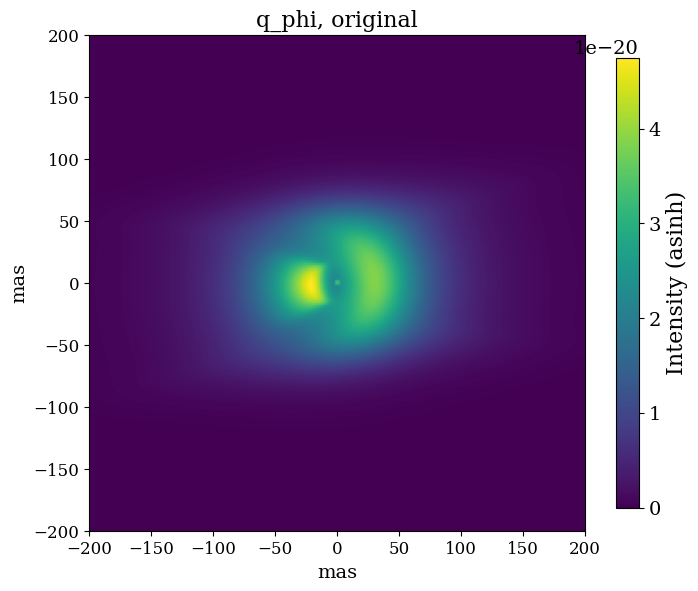

[obriy_polarimetry] ROI half size 100 too large for image shape (114, 114). Disabling cropping for plot.


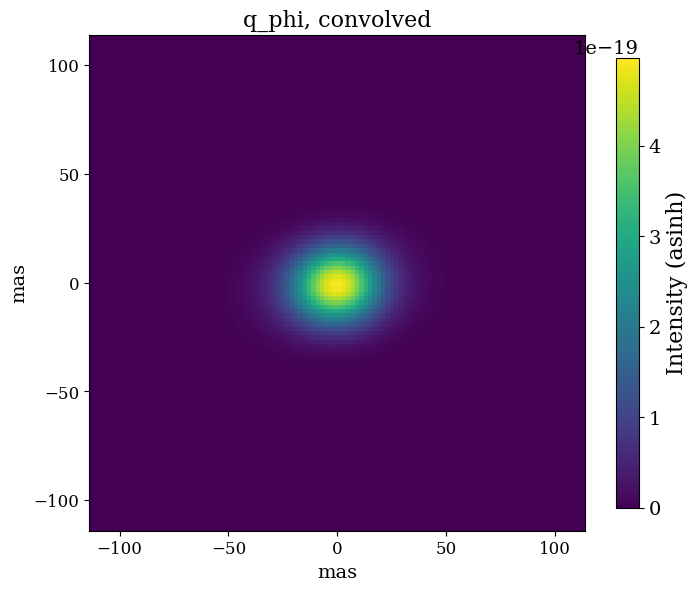

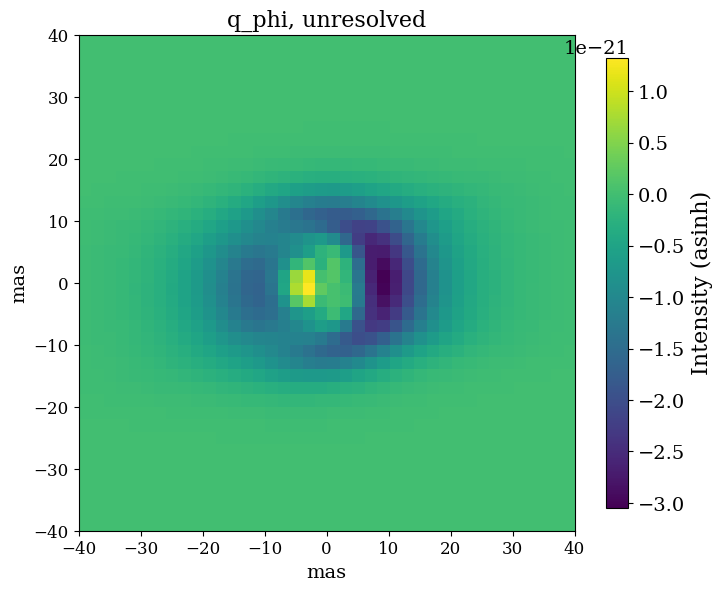

In [51]:
obp.plot_polarimetric_image(results_i['mcfost_original']['img_tot'], pix_scale_camera[camera], title=f'q_phi, original', image_scale='asinh', roi_half_size=100, show=True)

obp.plot_polarimetric_image(results_i['mcfost_convolved']['img_tot'], pix_scale_camera[camera], title=f'q_phi, convolved', image_scale='asinh', roi_half_size=100, show=True)
obp.plot_polarimetric_image(results_i['mcfost_not_convolved_unresolved_corrected']['q_phi'], pix_scale_camera[camera], title=f'q_phi, unresolved', image_scale='asinh', roi_half_size=20, show=True)


In [7]:
from typing import Tuple, Optional

def plot_polarimetric_image(
    image_to_plot: np.ndarray,
    ps_mas: Optional[float],
    *,
    image_scale: str = "linear",
    title: str = "",
    save: Optional[str] = None,
    show: bool = True,
    roi_half_size: Optional[int] = None,
    roi_center: Optional[Tuple[int, int]] = None,
    cmap_image: str = "viridis",
    cbar_label: Optional[str] = None,
    return_fig_ax: bool = False,
    aolp_quiver: bool = False,
    bin_factor: Tuple[int, int] = (4, 4),
    Q: Optional[np.ndarray]=None,
    U: Optional[np.ndarray]=None,
    I: Optional[np.ndarray]=None,
    snr_threshold: Optional[float] = 1,
    noise_level: Optional[float] = None,
    quiver_scale: Optional[float] = 0.1
) -> Optional[Tuple[plt.Figure, np.ndarray]]:
    """
    Status: not fully verified

    Plot an image with optional AoLP quiver field overlaid. To overplot AoLP quivers,
    Stokes Q, U and I must be provided. The quivers are oriented by AoLP and scaled by
    polarization fraction (estimated as image/I on binned maps).

    The function:
      1. Displays the image in pixel units or milliarcseconds (if `ps_mas` is given),
      2. Optionally rois to a square region of interest (ROI),
      3. Optionally bins the image (and Stokes maps, if provided) by integer factors,
      4. Optionally overlays quivers oriented by AoLP and scaled by polarization fraction,
      5. Optionally applies SNR masking for quiver vectors,
      6. Optionally outlines the mask region with contours.


    Parameters
    ----------
    image_to_plot : np.ndarray
        2D array to use as the background image (e.g. Q_phi, polarized intensity, or total intensity).
    ps_mas : float or None
        Pixel scale in milliarcseconds per pixel. If None, axes are shown in pixel units.
    image_scale : {"linear", "log", "asinh"}, default="linear"
        Scaling applied to the background image:
          * "linear" : raw values
          * "log"    : logarithmic scaling (values <= 0 will be masked)
          * "asinh"  : inverse hyperbolic sine stretch, useful for high dynamic range
    title : str, optional
        Title for the plot.
    save : str or None, optional
        Path to save the figure. If None, the figure is not saved.
    show : bool, default=True
        If True, display the figure with `plt.show()`.
    roi_half_size : int or None, optional
        Half-size of the square ROI. If provided, roi to a region
        of size (2*roi_half_size) × (2*roi_half_size) around `roi_center`.
    roi_center : (int, int) or None, optional
        Center (y, x) of the ROI. If None, the image center is used.
    cmap_image : str, default="viridis"
        Colormap for the background image.
    cbar_label : str, optional
        Label for the colorbar.
    return_fig_ax : bool, default=False
        If True, return (fig, ax) for further modification.
    aolp_quiver : bool, default=False
        If True, overlay AoLP quivers computed from Stokes Q and U.
        Requires Q, U, and I to be provided.
    bin_factor : (int, int), default=(4, 4)
        Integer binning factors (by_y, by_x) for plotting the AoLP quivers. 
        Must evenly divide the roiped image dimensions.
    Q, U, I : np.ndarray or None, optional
        Stokes Q, U, and total intensity maps. Needed only if `aolp_quiver=True`.
    snr_threshold : float or None, optional
        SNR threshold for masking quivers. Vectors are kept where
        image_to_plot >= snr_threshold * noise_level. Requires `noise_level`.
    noise_level : float or None, optional
        Noise estimate in the same units as `image_to_plot`. Used with `snr_threshold`.
    quiver_scale : float or None, default=0.1
        Scaling factor for quiver lengths passed to `ax.quiver`. If None, use Matplotlib defaults.
    Returns
    -------
    (fig, ax) or None
        Matplotlib Figure and Axes objects if `return_fig_ax=True`, otherwise None.

    Notes
    -----
    * AoLP is always recomputed from binned Q and U, not from pre-binned angles.
    * Polarization fraction is estimated as (image_to_plot / I) on binned data.
    * If `ps_mas` is given, axis labels are in mas; otherwise pixel coordinates are used.
    * This function is not yet fully verified.
    """

    # --- helpers ---
    def _center_crop(arr, half, center=None):
        if half is None:
            return arr
        ny, nx = arr.shape
        cy, cx = (ny // 2, nx // 2) if center is None else center
        y0, y1 = cy - half, cy + half
        x0, x1 = cx - half, cx + half
        return arr[y0:y1, x0:x1]

    def _block_reduce_sum(a: np.ndarray, by: int, bx: int) -> np.ndarray:
        """Sum-reduce in (y,x) blocks of (by,bx). Assumes divisibility."""
        ny, nx = a.shape
        if ny % by != 0 or nx % bx != 0:
            raise ValueError(f"Array shape {a.shape} not divisible by bin_factor {(by, bx)}")
        return a.reshape(ny // by, by, nx // bx, bx).sum(axis=(1, 3))

    ################################################################################
    # --- input checks ---

    allowed_scales = {"linear", "log", "asinh"}
    if image_scale not in allowed_scales:
        raise ValueError(
            f"Invalid image_scale '{image_scale}'. "
            f"Choose one of {allowed_scales}."
        )

    if aolp_quiver:
        if Q is None or U is None or I is None:
            raise ValueError("To plot AoLP quivers, Stokes Q, U and I must be provided.")
        if not (Q.shape == U.shape == I.shape == image_to_plot.shape):
            raise ValueError("All input maps must have the same shape.")

    # ---   p (optional) ---
    if roi_half_size is not None:
        image_to_plot = _center_crop(image_to_plot, roi_half_size, roi_center)
        if aolp_quiver:
            Q = _center_crop(Q, roi_half_size, roi_center)
            U = _center_crop(U, roi_half_size, roi_center)
            I = _center_crop(I, roi_half_size, roi_center)



    ny, nx = image_to_plot.shape

    # --- figure/axes ---
    fig, ax = plt.subplots(figsize=(8, 8))

    # --- extent in mas or pixels ---
    if ps_mas is not None:
        half_w_mas = (nx * ps_mas) / 2.0
        half_h_mas = (ny * ps_mas) / 2.0
        extent = (-half_w_mas, half_w_mas, -half_h_mas, half_h_mas)  # (x_min, x_max, y_min, y_max)
        xlabel, ylabel = "mas", "mas"
    else:
        extent = (-(nx / 2), (nx / 2), -(ny / 2), (ny / 2))
        xlabel, ylabel = "pixel", "pixel"

    # --- background plot ---
    if image_scale == "linear":
        img_display = image_to_plot
        if cbar_label is None:
            cbar_label = "Intensity (linear)"
    elif image_scale == "log":
        img_display = np.where(image_to_plot > 0, np.log10(image_to_plot), np.nan)
        if cbar_label is None:
            cbar_label = "Intensity (log10)"
    elif image_scale == "asinh":
        img_display = np.arcsinh(image_to_plot)
        if cbar_label is None:
            cbar_label = "Intensity (asinh)"

    im = ax.imshow(img_display, origin="lower", cmap=cmap_image, extent=extent, aspect="equal")
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.73)
    cbar.set_label(cbar_label)

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis="both", labelsize=12)


    # --- quiver overlay (optional) ---
    if aolp_quiver:
        by, bx = bin_factor

        # --- bin maps (sum) ---
        # Use sums for Q/U/I so that AoLP is computed from vector sums; fraction computed from binned Qphi/I.
        image_to_plot_b = _block_reduce_sum(image_to_plot, by, bx)
        if aolp_quiver:
            Q_b = _block_reduce_sum(Q, by, bx)
            U_b = _block_reduce_sum(U, by, bx)
            I_b = _block_reduce_sum(I, by, bx)

        ny_b, nx_b = image_to_plot_b.shape

        # --- coordinates for quiver centers in the same units as the extent ---
        if ps_mas is not None:
            xs = np.linspace(-half_w_mas + (ps_mas * bx) / 2, half_w_mas - (ps_mas * bx) / 2, nx_b)
            ys = np.linspace(-half_h_mas + (ps_mas * by) / 2, half_h_mas - (ps_mas * by) / 2, ny_b)
        else:
            xs = np.linspace(-(nx / 2) + bx / 2, (nx / 2) - bx / 2, nx_b)
            ys = np.linspace(-(ny / 2) + by / 2, (ny / 2) - by / 2, ny_b)

        Xc, Yc = np.meshgrid(xs, ys)


        # --- recompute AoLP (psi) from binned Q/U ---
        psi = 0.5 * np.arctan2(U_b, Q_b)  # radians

        # --- polarization fraction (simple estimator) ---
        with np.errstate(divide="ignore", invalid="ignore"):
            frac = np.where(I_b != 0.0, image_to_plot_b / I_b, 0.0)

        # --- masking ---
        mask = np.ones_like(image_to_plot_b, dtype=bool)
        if snr_threshold is not None:
            if noise_level is None:
                raise ValueError("`noise_level` must be provided when using `snr_threshold`.")
            mask &= (image_to_plot_b >= snr_threshold * noise_level)


        # Rotate by +pi/2 to follow usual convention (vectors start from North and increase to East).
        dx = frac * np.cos(psi + np.pi / 2.0)
        dy = frac * np.sin(psi + np.pi / 2.0)

        quiv_kwargs = dict(headlength=0, headwidth=1, pivot="middle", color="w")
        if quiver_scale is not None:
            quiv_kwargs["scale"] = quiver_scale

        ax.quiver(Xc[mask], Yc[mask], dx[mask], dy[mask], **quiv_kwargs)

        # optional: outline the mask
        try:
            # Build an integer mask for contouring (0/1)
            mask_int = mask.astype(int)
            ax.contour(
                Xc, Yc, mask_int,
                levels=[0.5], colors=["white"], linewidths=0.8
            )
        except Exception:
            pass

    ax.set_title(title, fontsize=16)
    plt.tight_layout()
    #
    # if save:
    #     plt.savefig(save, bbox_inches="tight", pad_inches=0.1)

    if show:
        plt.show()
    else:
        plt.close(fig)

    if return_fig_ax:
        return fig, ax
    return None

In [8]:
from scipy.ndimage import rotate


def transformtodisk(Q, U, angle):
    '''
    Transforms Stokes parameters from sky coordinates to disk coordinates using a geometric rotation.

    We load Stokes Q and U images in sky coordinates and use a geometric rotation
    (Equations 7 and 8 from Schmid 2021) to transform the Q and U into the disk coordinate system.
    This preserves the brightness distribution of the disk's lobes. The function then
    plots and saves the transformed image.

    The paper for each equation is found here: https://www.aanda.org/articles/aa/pdf/2021/11/aa40405-21.pdf, titled Quadrant polarization parameters for the scattered light of circumstellar disks by H. M. Schmid (2021).

    The angle, omega, aligns the disk's major and minor axes with the plot's x and y
    axes, with the "front" of the disk (brightest/closest part) located at the bottom.

    Input parameters:
    dir (str): The directory path where the FITS images are located.
    angle (float): The rotation angle in degrees (omega). The transformation is based on this angle.
    stokes (str): The specific Stokes parameter to compute and return ('Q' or 'U').
    band (str): The photometric band of the observation (e.g., 'I', 'V', 'H').
                Used to form the input filenames.
    lim (int): The half-width in pixels for the plot's x and y limits, centered on the image.
    verbose (bool): If True, displays the plot on the screen.

    Outputs:
    rotated_stokes (arr): The transformed image data as a NumPy array.
    '''

    # load data
    # rotate image
    w = np.deg2rad(angle)               # convert omega to radians
    # pre-calculate cos(2*omega) and sin(2*omega)
    cos2w = np.cos(2*w)
    sin2w = np.sin(2*w)

    cw, sw = np.cos(w), np.sin(w)
    R, x_s, y_s, _, _ =obp.compute_grid(Q)

    x = x_s * cw + y_s * sw
    y = y_s * cw - x_s * sw
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    phi=np.arctan2(Y, X)+np.pi/2  # azimuthal angle in disk coordinates (0 at North, increasing to East)

    # perform the geometric transformation to disk coordinates based on the selected Stokes parameter

    rotated_Q= Q * cos2w + U * sin2w       # equation for Q_disk (7)

    rotated_U = U * cos2w - Q * sin2w       # equation for U_disk (8)

    rotated_Q = rotate(rotated_Q, angle, reshape=False)
    rotated_U = rotate(rotated_U, angle, reshape=False)



    return rotated_Q, rotated_U, x, y, R, phi


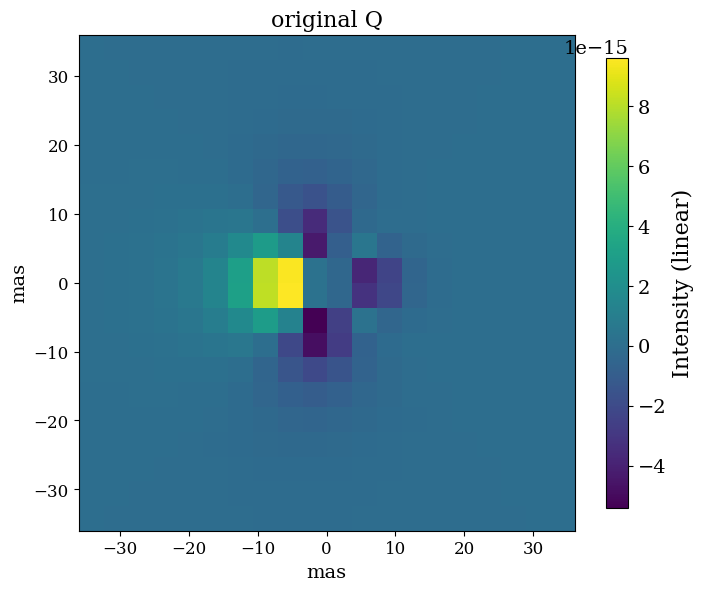

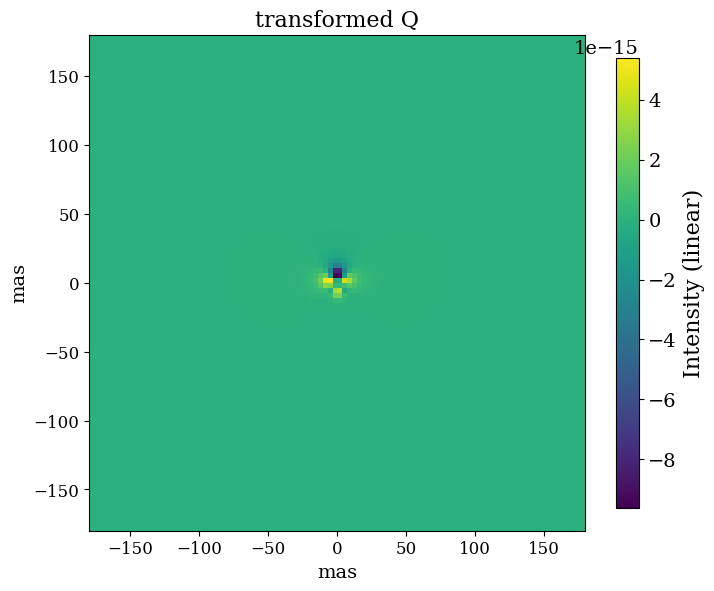

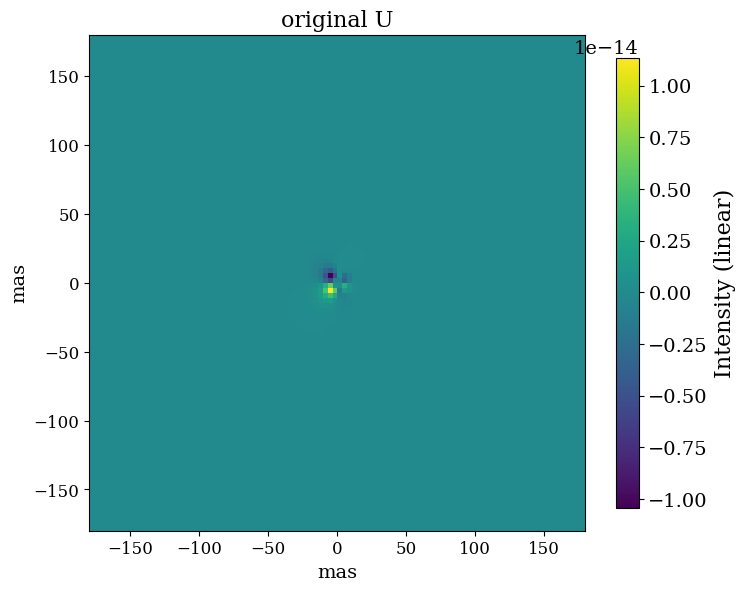

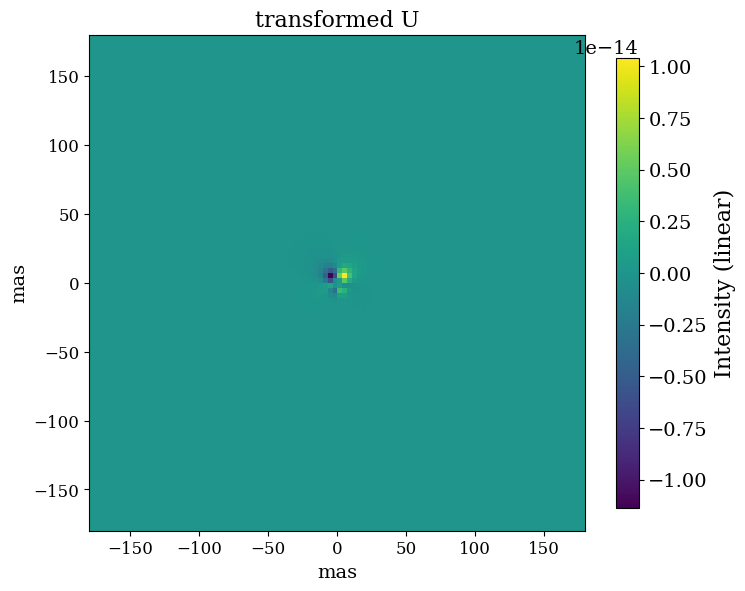

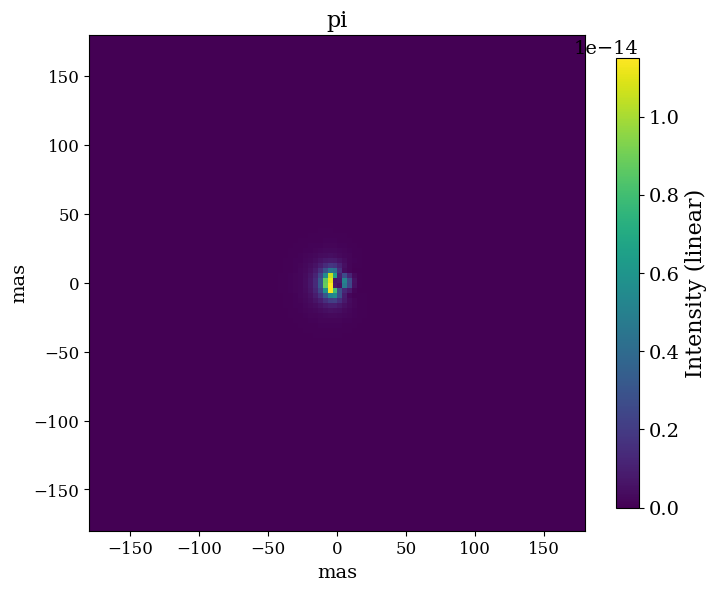

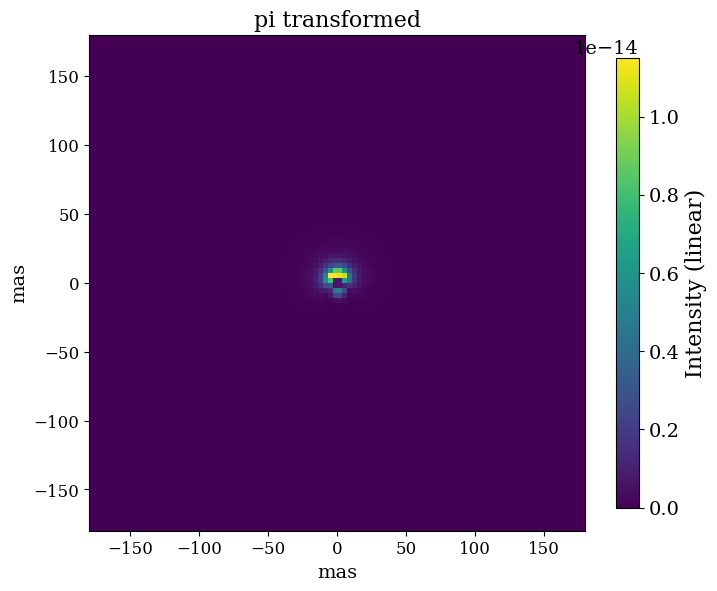

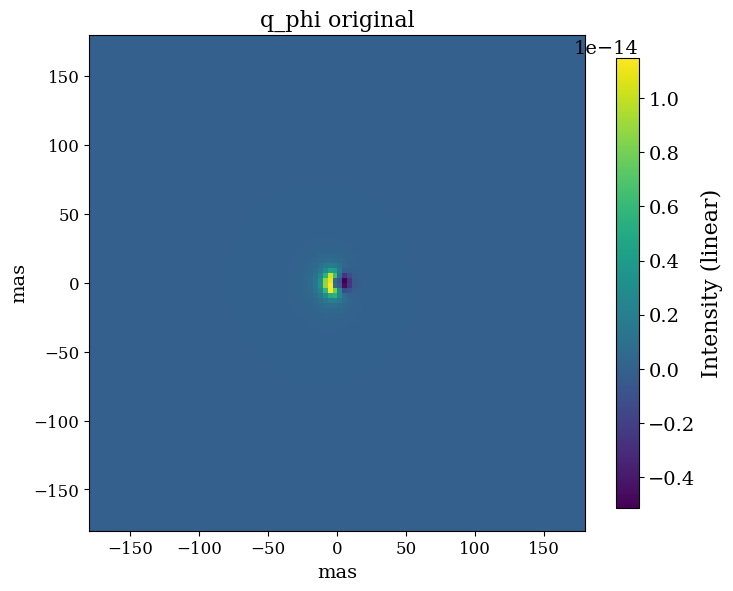

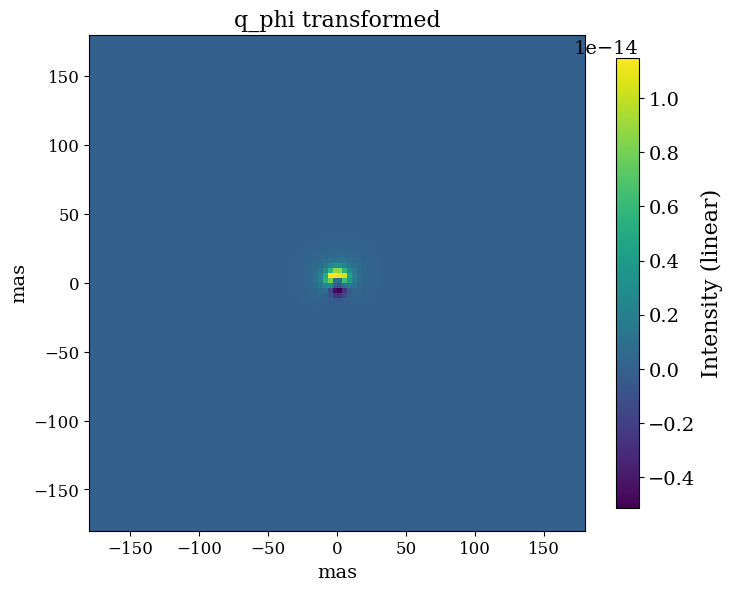

In [9]:
q_phi=results_i['mcfost_rescaled']['q_phi']
img_q=results_i['mcfost_rescaled']['img_q']
img_u=results_i['mcfost_rescaled']['img_u']
pi=results_i['mcfost_rescaled']['pi']


Q_d, U_d, x_d, y_d, R_d, phi_d = transformtodisk(img_q, img_u, 90)

obp.plot_polarimetric_image(img_q,pix_scale_camera[camera],roi_half_size=10, title='original Q', show=True)
obp.plot_polarimetric_image(Q_d,pix_scale_camera[camera], roi_half_size=50, title='transformed Q', show=True)

obp.plot_polarimetric_image(img_u,pix_scale_camera[camera], roi_half_size=50, title='original U', show=True)
obp.plot_polarimetric_image(U_d,pix_scale_camera[camera], roi_half_size=50, title='transformed U', show=True)



R, x, y, X,Y=obp.compute_grid(Q_d)
phi=np.arctan2(Y, X)-np.pi/2 # azimuthal angle in disk coordinates (0 at North, increasing to East)

pi_d=np.sqrt(Q_d**2+U_d**2)
#pi_d[(phi>0)&(phi<np.deg2rad(10))]=1
obp.plot_polarimetric_image(pi,pix_scale_camera[camera], roi_half_size=50, title='pi', show=True)

obp.plot_polarimetric_image(pi_d,pix_scale_camera[camera], roi_half_size=50, title='pi transformed', show=True)


q_phi_disc=-Q_d*np.cos(2*phi)-U_d*np.sin(2*phi)
u_phi_disc=Q_d*np.sin(2*phi)-U_d*np.cos(2*phi)

obp.plot_polarimetric_image(q_phi,pix_scale_camera[camera], roi_half_size=50, title='q_phi original', show=True)
obp.plot_polarimetric_image(q_phi_disc,pix_scale_camera[camera], roi_half_size=50, title='q_phi transformed', show=True)



In [19]:
def differential_quadrants(
    Q,
    U,
    pixel_scale_mas,
    disk_pa_deg,
    r_in_mas,
    r_out_mas,
    *,
    flip_disk_y=False,
    plot=False,
    save=None,
    title=None,
    roi_mas=None,
):
    """
    Calculate Schmid differential quadrant parameters.

    Coordinate convention
    ---------------------
    Input images:
        +X_sky = East
        +Y_sky = North

    disk_pa_deg:
        Position angle of the DISK MAJOR AXIS,
        measured North -> East.

    Schmid disk coordinates:
        +x_disk = along disk major axis
        +y_disk = along disk minor axis

        phi_disk = atan2(x_disk, y_disk)

        so:
            phi =   0 deg : +y_disk
            phi =  90 deg : +x_disk
            phi = 180 deg : -y_disk
            phi = 270 deg : -x_disk

    flip_disk_y:
        If False, +y_disk is chosen 90 deg counter-clockwise
        from +x_disk in the PA convention.
        Set True if the opposite minor-axis direction should
        correspond to +y_disk (e.g. to make +y the disk backside).

    Notes
    -----
    - No scipy image rotation/interpolation is performed.
    - Q/U are rotated analytically into the disk Stokes basis.
    - Quadrants are defined in disk coordinates.
    - Q_phi and P are recomputed in the disk frame as a consistency check.
    - P = sqrt(Q^2 + U^2) is invariant under coordinate rotation.

    Returns
    -------
    dict
        Raw quadrant sums, differential quadrant values,
        normalized differential values, and coordinate/validation
        quantities useful for diagnostics.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle

    # =========================================================
    # 0. Basic checks
    # =========================================================

    Q = np.asarray(Q, dtype=float)
    U = np.asarray(U, dtype=float)

    if Q.shape != U.shape:
        raise ValueError(
            f"Q and U must have the same shape: "
            f"Q={Q.shape}, U={U.shape}"
        )

    if r_out_mas <= r_in_mas:
        raise ValueError("r_out_mas must be larger than r_in_mas.")

    # =========================================================
    # 1. Sky coordinates
    # =========================================================

    ny, nx = Q.shape

    yc = (ny - 1) / 2.0
    xc = (nx - 1) / 2.0

    yy, xx = np.indices(Q.shape)

    # Astronomical sky convention:
    # +X = East
    # +Y = North
    X = (xx - xc) * pixel_scale_mas
    Y = -(yy - yc) * pixel_scale_mas

    R = np.sqrt(X**2 + Y**2)

    # PA measured from North toward East
    phi_sky = np.arctan2(X, Y)

    # =========================================================
    # 2. Define Schmid disk coordinate system
    # =========================================================

    # Input PA is MAJOR-axis PA.
    pa_major = np.deg2rad(disk_pa_deg)

    # In Schmid coordinates:
    #
    #   +x_disk = major axis
    #   +y_disk = minor axis
    #
    # Since phi = atan2(x,y), +x occurs 90 deg from +y.
    #
    # Therefore:
    # PA(+y_disk) = PA(+x_disk) - 90 deg

    w = pa_major - np.pi / 2.0

    if flip_disk_y:
        # Reverse both disk axes.
        #
        # Note: this does NOT change the Q/U Stokes basis because
        # Stokes Q,U are invariant under a 180-deg axis reversal,
        # but it DOES swap the physical quadrant labels.
        w += np.pi

    # =========================================================
    # 3. Spatial coordinates in disk frame
    # =========================================================

    # This is a passive coordinate transformation.
    #
    # A point exactly along +y_disk should give:
    # Xd = 0, Yd > 0

    Xd = X * np.cos(w) - Y * np.sin(w)
    Yd = X * np.sin(w) + Y * np.cos(w)

    # Schmid azimuth:
    # phi = atan2(x_disk, y_disk)
    phi = np.arctan2(Xd, Yd)
    phi_mod = phi % (2.0 * np.pi)

    # Useful consistency check:
    phi_from_sky = np.angle(
        np.exp(1j * (phi_sky - w))
    )

    # =========================================================
    # 4. Rotate Stokes Q/U basis into disk coordinates
    # =========================================================

    cos2w = np.cos(2.0 * w)
    sin2w = np.sin(2.0 * w)

    Qd = Q * cos2w + U * sin2w
    Ud = U * cos2w - Q * sin2w

    # =========================================================
    # 5. Q_phi, U_phi and P in disk coordinates
    # =========================================================

    # Schmid & Ma equations:
    #
    # Q_phi = -Q cos(2phi) - U sin(2phi)
    # U_phi = +Q sin(2phi) - U cos(2phi)

    Qphi_disk = (
        -Qd * np.cos(2.0 * phi)
        -Ud * np.sin(2.0 * phi)
    )

    Uphi_disk = (
        +Qd * np.sin(2.0 * phi)
        -Ud * np.cos(2.0 * phi)
    )

    # Polarized flux P.
    # This is invariant under the Q/U reference-frame rotation.
    P_disk = np.sqrt(Qd**2 + Ud**2)

    # Calculate using your existing routine as a cross-check
    Qphi_sky, Uphi_sky, P_sky, _ = obp.compute_qphi_uphi_pi(Q, U)

    finite = (
        np.isfinite(Qphi_disk)
        & np.isfinite(Qphi_sky)
    )

    if np.any(finite):
        max_qphi_difference = np.nanmax(
            np.abs(Qphi_disk[finite] - Qphi_sky[finite])
        )
    else:
        max_qphi_difference = np.nan

    finite_p = (
        np.isfinite(P_disk)
        & np.isfinite(P_sky)
    )

    if np.any(finite_p):
        max_p_difference = np.nanmax(
            np.abs(P_disk[finite_p] - P_sky[finite_p])
        )
    else:
        max_p_difference = np.nan

    # =========================================================
    # 6. Integration aperture
    # =========================================================

    aperture = (
        (R >= r_in_mas)
        & (R <= r_out_mas)
        & np.isfinite(Qd)
        & np.isfinite(Ud)
    )

    # =========================================================
    # 7. Non-overlapping quadrant masks
    # =========================================================

    def angular_difference(phi_array, center_deg):
        """
        Wrapped angular difference in [-pi, pi).
        """
        center = np.deg2rad(center_deg)

        return np.angle(
            np.exp(1j * (phi_array - center))
        )

    def wedge(center_deg):
        """
        90-degree wedge centred on center_deg.

        The lower boundary is included and the upper boundary
        excluded so neighbouring wedges cannot double-count pixels.
        """
        dphi = angular_difference(phi, center_deg)

        return (
            aperture
            & (dphi >= -np.pi / 4.0)
            & (dphi <  np.pi / 4.0)
        )

    # =========================================================
    # 8. Q quadrants
    # =========================================================

    Q000 = np.nansum(Qd[wedge(0)])
    Q090 = np.nansum(Qd[wedge(90)])
    Q180 = np.nansum(Qd[wedge(180)])
    Q270 = np.nansum(Qd[wedge(270)])

    # =========================================================
    # 9. U quadrants
    # =========================================================

    U045 = np.nansum(Ud[wedge(45)])
    U135 = np.nansum(Ud[wedge(135)])
    U225 = np.nansum(Ud[wedge(225)])
    U315 = np.nansum(Ud[wedge(315)])

    # =========================================================
    # 10. Integrated quantities
    # =========================================================

    # Better than summing the four quadrant values because this
    # guarantees every aperture pixel is counted exactly once.
    SigmaQ = np.nansum(Qd[aperture])
    SigmaU = np.nansum(Ud[aperture])

    # Use Qphi calculated self-consistently in disk coordinates.
    SigmaQphi = np.nansum(Qphi_disk[aperture])

    # Pixel-wise integrated polarized flux:
    #
    # SigmaP = sum sqrt(Q^2 + U^2)
    #
    # Note: this is NOT the same as aperture polarization:
    # P(Sigma) = sqrt[(SigmaQ)^2 + (SigmaU)^2]
    SigmaP = np.nansum(P_disk[aperture])

    P_aperture = np.sqrt(SigmaQ**2 + SigmaU**2)

    # =========================================================
    # 11. Differential quadrant parameters
    # =========================================================

    dQ000 = Q000 - SigmaQ / 4.0
    dQ090 = Q090 - SigmaQ / 4.0
    dQ180 = Q180 - SigmaQ / 4.0
    dQ270 = Q270 - SigmaQ / 4.0

    dUplus = U135 - U045
    dUminus = U225 - U315

    # Relative quantities only meaningful if SigmaQphi != 0.
    valid = (
        np.isfinite(SigmaQphi)
        and not np.isclose(
            SigmaQphi,
            0.0,
            atol=1e-12,
            rtol=0.0
        )
    )

    if valid:

        dQ000_norm = dQ000 / SigmaQphi
        dQ090_norm = dQ090 / SigmaQphi
        dQ180_norm = dQ180 / SigmaQphi
        dQ270_norm = dQ270 / SigmaQphi

        dUplus_norm = dUplus / SigmaQphi
        dUminus_norm = dUminus / SigmaQphi

    else:

        print(
            f"Warning: SigmaQphi ~ 0 in annulus "
            f"{r_in_mas}..{r_out_mas} mas. "
            "Normalized quadrant quantities set to NaN."
        )

        dQ000_norm = np.nan
        dQ090_norm = np.nan
        dQ180_norm = np.nan
        dQ270_norm = np.nan

        dUplus_norm = np.nan
        dUminus_norm = np.nan

    # =========================================================
    # 12. Results
    # =========================================================

    result = {

        # Raw Q quadrants
        "Q000": Q000,
        "Q090": Q090,
        "Q180": Q180,
        "Q270": Q270,

        # Raw U quadrants
        "U045": U045,
        "U135": U135,
        "U225": U225,
        "U315": U315,

        # Integrated quantities
        "SigmaQ": SigmaQ,
        "SigmaU": SigmaU,
        "SigmaQphi": SigmaQphi,
        "SigmaP": SigmaP,
        "P_aperture": P_aperture,

        # Raw differential quantities
        "dQ000": dQ000,
        "dQ090": dQ090,
        "dQ180": dQ180,
        "dQ270": dQ270,

        "dUplus": dUplus,
        "dUminus": dUminus,

        # Normalized differential quantities
        "dQ000_norm": dQ000_norm,
        "dQ090_norm": dQ090_norm,
        "dQ180_norm": dQ180_norm,
        "dQ270_norm": dQ270_norm,

        "dUplus_norm": dUplus_norm,
        "dUminus_norm": dUminus_norm,

        "valid": valid,

        # Geometry
        "disk_pa_major_deg": disk_pa_deg,
        "disk_y_pa_deg": np.rad2deg(w) % 360.0,
        "flip_disk_y": flip_disk_y,

        # Useful maps
        "Q_disk": Qd,
        "U_disk": Ud,
        "Qphi_disk": Qphi_disk,
        "Uphi_disk": Uphi_disk,
        "P_disk": P_disk,

        "X_disk": Xd,
        "Y_disk": Yd,
        "R": R,
        "phi_disk": phi_mod,
        "aperture": aperture,

        # Coordinate / convention diagnostics
        "max_Qphi_coordinate_difference": max_qphi_difference,
        "max_P_coordinate_difference": max_p_difference,
    }

    # =========================================================
    # 13. Diagnostic plots
    # =========================================================

    if plot:

        if roi_mas is None:
            roi_mas = 1.2 * r_out_mas

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(11, 10),
            constrained_layout=True
        )

        axQ = axes[0, 0]
        axU = axes[0, 1]
        axQphi = axes[1, 0]
        axP = axes[1, 1]

        # -----------------------------------------------------
        # Plot helpers
        # -----------------------------------------------------

        def draw_radial_line(
            ax,
            angle_deg,
            radius,
            **kwargs
        ):
            """
            Disk angle measured from +y toward +x.
            """
            a = np.deg2rad(angle_deg)

            x_end = radius * np.sin(a)
            y_end = radius * np.cos(a)

            ax.plot(
                [0, x_end],
                [0, y_end],
                **kwargs
            )

        def annotate_quadrant(
            ax,
            angle_deg,
            radius,
            text
        ):
            a = np.deg2rad(angle_deg)

            x_text = radius * np.sin(a)
            y_text = radius * np.cos(a)

            ax.text(
                x_text,
                y_text,
                text,
                ha="center",
                va="center",
                fontsize=9,
                bbox=dict(
                    facecolor="white",
                    alpha=0.75,
                    edgecolor="none"
                )
            )

        def add_aperture(ax):
            ax.add_patch(
                Circle(
                    (0, 0),
                    r_in_mas,
                    fill=False,
                    ls=":",
                    lw=1.2,
                    color="k"
                )
            )

            ax.add_patch(
                Circle(
                    (0, 0),
                    r_out_mas,
                    fill=False,
                    ls="-",
                    lw=1.2,
                    color="k"
                )
            )

        def format_disk_axes(ax):
            ax.axhline(
                0,
                lw=0.5,
                alpha=0.35,
                color="k"
            )

            ax.axvline(
                0,
                lw=0.5,
                alpha=0.35,
                color="k"
            )

            ax.set_xlim(-roi_mas, roi_mas)
            ax.set_ylim(-roi_mas, roi_mas)

            ax.set_aspect("equal")

            ax.set_xlabel(
                r"$x_{\rm disk}$ [mas]  (major axis)"
            )

            ax.set_ylabel(
                r"$y_{\rm disk}$ [mas]  (minor axis)"
            )

        # -----------------------------------------------------
        # Common Q/U scale
        # -----------------------------------------------------

        qu_values = np.concatenate([
            np.abs(Qd[np.isfinite(Qd)]),
            np.abs(Ud[np.isfinite(Ud)])
        ])

        vmax_qu = np.nanpercentile(
            qu_values,
            99
        )

        if (
            not np.isfinite(vmax_qu)
            or vmax_qu == 0
        ):
            vmax_qu = 1.0

        # =====================================================
        # Q_disk
        # =====================================================

        imQ = axQ.pcolormesh(
            Xd,
            Yd,
            Qd,
            shading="auto",
            cmap="RdBu_r",
            vmin=-vmax_qu,
            vmax=vmax_qu,
        )

        # Q centres:
        # 0, 90, 180, 270
        #
        # boundaries:
        # 45, 135, 225, 315
        for angle in [45, 135, 225, 315]:
            draw_radial_line(
                axQ,
                angle,
                r_out_mas,
                color="k",
                lw=1,
                ls="--"
            )

        add_aperture(axQ)

        r_label = (
            r_in_mas
            + 0.68 * (r_out_mas - r_in_mas)
        )

        annotate_quadrant(
            axQ, 0, r_label, "Q000"
        )
        annotate_quadrant(
            axQ, 90, r_label, "Q090"
        )
        annotate_quadrant(
            axQ, 180, r_label, "Q180"
        )
        annotate_quadrant(
            axQ, 270, r_label, "Q270"
        )

        if valid:
            axQ.set_title(
                r"$Q_{\rm disk}$"
                "\n"
                rf"$\Delta Q_{{000}}/\Sigma Q_\phi"
                rf"={dQ000_norm:.3f}$, "
                rf"$090={dQ090_norm:.3f}$"
                "\n"
                rf"$180={dQ180_norm:.3f}$, "
                rf"$270={dQ270_norm:.3f}$"
            )
        else:
            axQ.set_title(
                r"$Q_{\rm disk}$"
                "\n"
                r"$\Sigma Q_\phi \approx 0$"
            )

        format_disk_axes(axQ)

        fig.colorbar(
            imQ,
            ax=axQ,
            label=r"$Q_{\rm disk}$"
        )

        # =====================================================
        # U_disk
        # =====================================================

        imU = axU.pcolormesh(
            Xd,
            Yd,
            Ud,
            shading="auto",
            cmap="RdBu_r",
            vmin=-vmax_qu,
            vmax=vmax_qu,
        )

        # U centres:
        # 45,135,225,315
        #
        # boundaries:
        # 0,90,180,270
        for angle in [0, 90, 180, 270]:
            draw_radial_line(
                axU,
                angle,
                r_out_mas,
                color="k",
                lw=1,
                ls="--"
            )

        add_aperture(axU)

        annotate_quadrant(
            axU, 45, r_label, "U045"
        )
        annotate_quadrant(
            axU, 135, r_label, "U135"
        )
        annotate_quadrant(
            axU, 225, r_label, "U225"
        )
        annotate_quadrant(
            axU, 315, r_label, "U315"
        )

        if valid:
            axU.set_title(
                r"$U_{\rm disk}$"
                "\n"
                rf"$\Delta U_+/\Sigma Q_\phi"
                rf"={dUplus_norm:.3f}$, "
                rf"$\Delta U_-/\Sigma Q_\phi"
                rf"={dUminus_norm:.3f}$"
            )
        else:
            axU.set_title(
                r"$U_{\rm disk}$"
                "\n"
                r"$\Sigma Q_\phi \approx 0$"
            )

        format_disk_axes(axU)

        fig.colorbar(
            imU,
            ax=axU,
            label=r"$U_{\rm disk}$"
        )

        # =====================================================
        # Q_phi
        # =====================================================

        qphi_values = np.abs(
            Qphi_disk[np.isfinite(Qphi_disk)]
        )

        vmax_qphi = np.nanpercentile(
            qphi_values,
            100
        )

        if (
            not np.isfinite(vmax_qphi)
            or vmax_qphi == 0
        ):
            vmax_qphi = 1.0

        imQphi = axQphi.pcolormesh(
            Xd,
            Yd,
            Qphi_disk,
            shading="auto",
            cmap="RdBu_r"
        )

        add_aperture(axQphi)
        format_disk_axes(axQphi)

        axQphi.set_title(
            r"$Q_\phi$ in disk coordinates"
            "\n"
            rf"$\Sigma Q_\phi={SigmaQphi:.3g}$"
        )

        fig.colorbar(
            imQphi,
            ax=axQphi,
            label=r"$Q_\phi$"
        )

        # =====================================================
        # Polarized flux P
        # =====================================================

        p_values = P_disk[np.isfinite(P_disk)]

        vmax_p = np.nanpercentile(
            p_values,
            100
        )

        if (
            not np.isfinite(vmax_p)
            or vmax_p == 0
        ):
            vmax_p = 1.0

        imP = axP.pcolormesh(
            Xd,
            Yd,
            P_disk,
            shading="auto",
            cmap="inferno"
        )

        add_aperture(axP)
        format_disk_axes(axP)

        axP.set_title(
            r"$P=\sqrt{Q^2+U^2}$ in disk coordinates"
            "\n"
            rf"$\Sigma P={SigmaP:.3g}$"
        )

        fig.colorbar(
            imP,
            ax=axP,
            label=r"$P$"
        )

        # =====================================================
        # Overall title
        # =====================================================

        base_title = (
            rf"Major-axis PA = {disk_pa_deg:.1f}$^\circ$"
            rf";  +$y_{{\rm disk}}$ PA = "
            rf"{np.rad2deg(w) % 360:.1f}$^\circ$"
        )

        if title is not None:
            fig.suptitle(
                title + "\n" + base_title,
                fontsize=13
            )
        else:
            fig.suptitle(
                base_title,
                fontsize=13
            )

        if save is not None:
            fig.savefig(
                save,
                dpi=200,
                bbox_inches="tight"
            )

        plt.show()

    return result

In [20]:
print(results_i.keys())

dict_keys(['mcfost_original', 'mcfost_rescaled', 'mcfost_convolved', 'mcfost_not_convolved_unresolved_corrected', 'mcfost_convolved_unresolved_corrected'])


Max value of q_phi: 7.863e-16, order of magnitude: -16


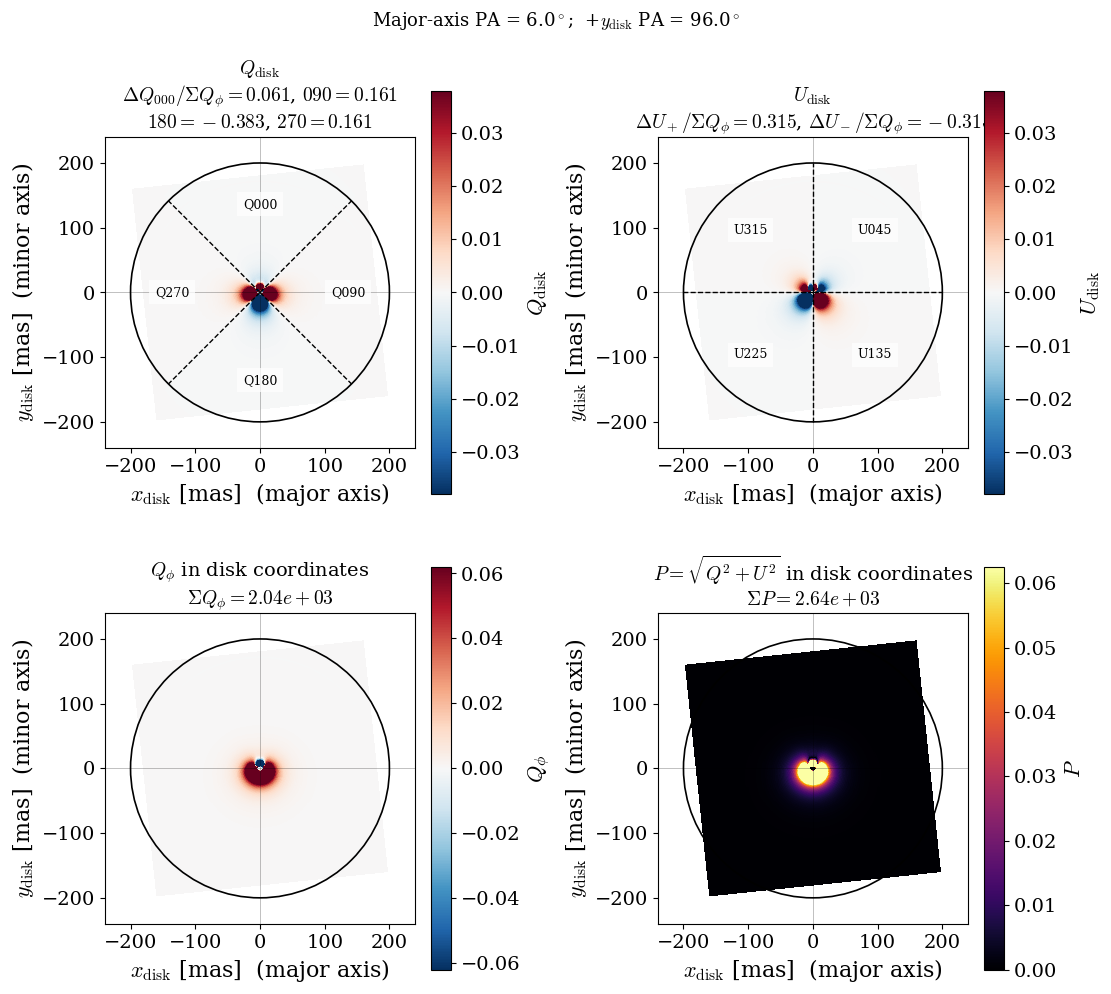

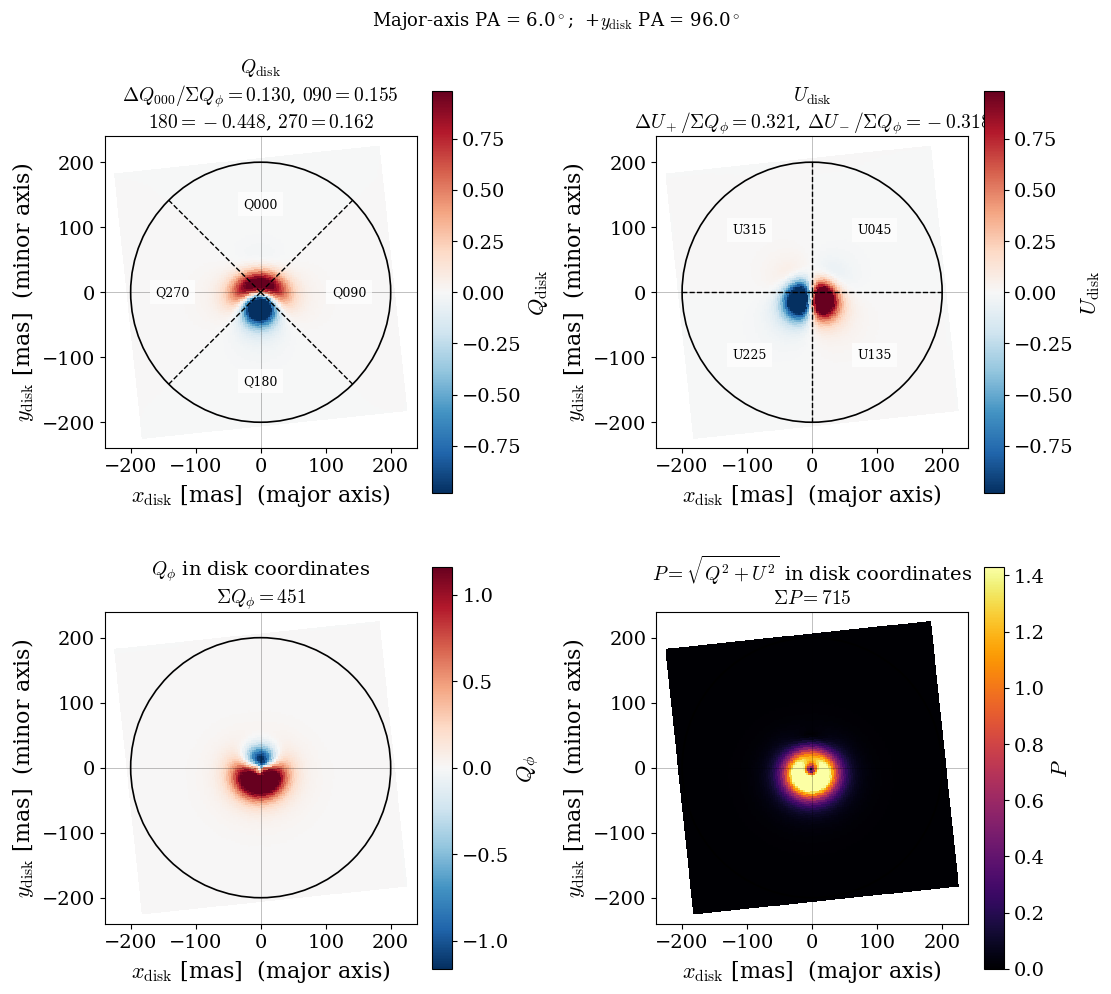

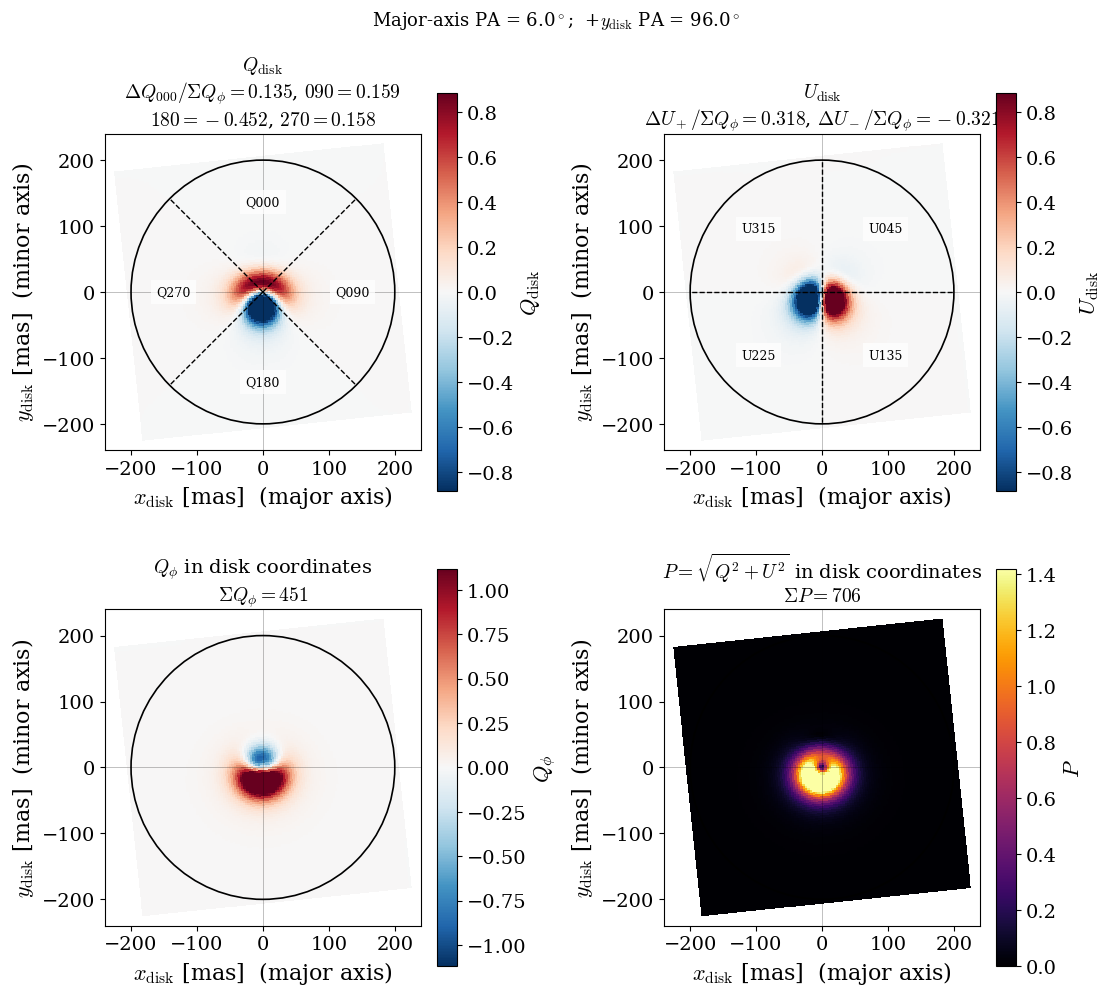

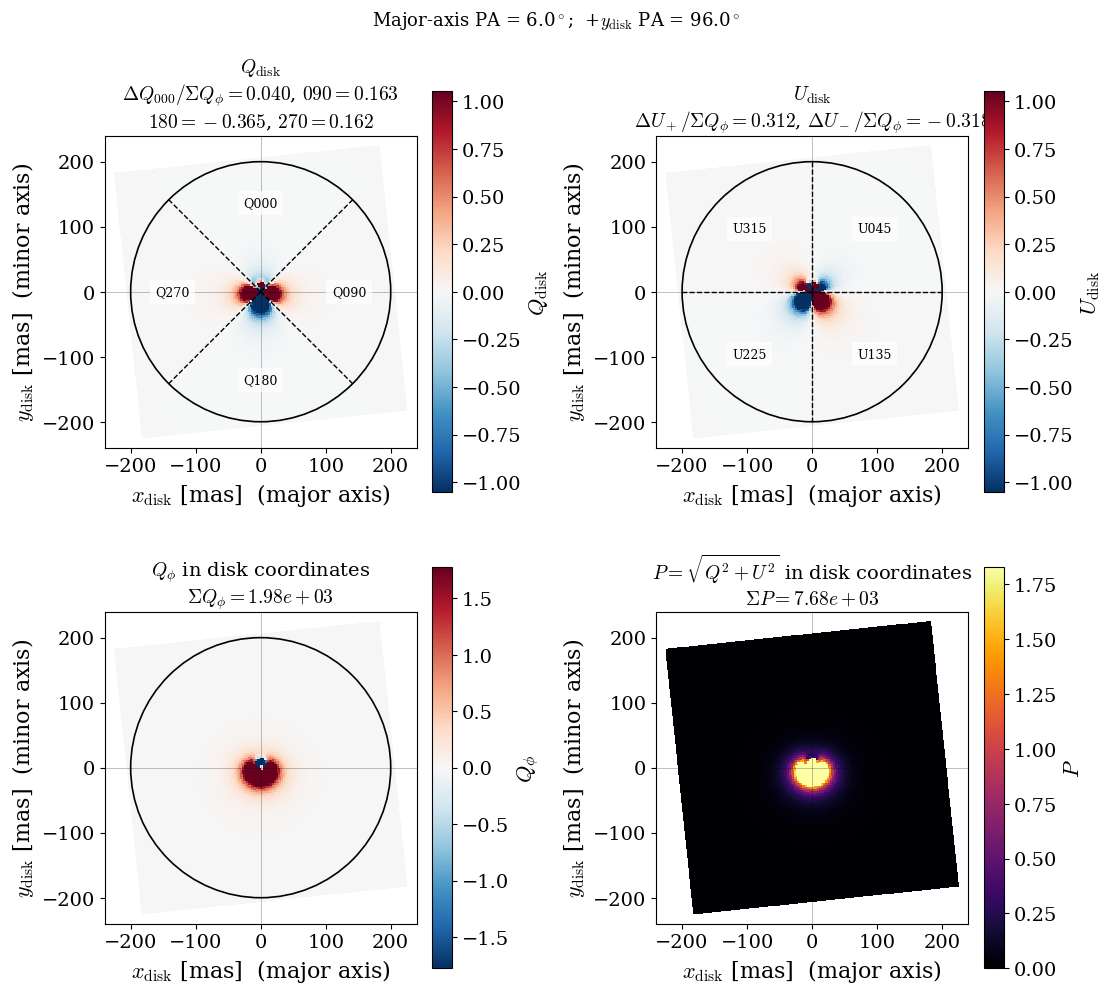

Qphi rotation consistency: 1.7763568394002505e-15
P rotation consistency: 8.881784197001252e-16
{'Q000': 133.50561107053667, 'Q090': 338.826229231617, 'Q180': -772.9325748143904, 'Q270': 339.3768407629445, 'U045': 15.626660168879425, 'U135': 659.8605437240113, 'U225': -661.1149015162457, 'U315': -16.755341998775947, 'SigmaQ': 38.7761062507076, 'SigmaU': -2.383039622131031, 'SigmaQphi': 2042.3575294798636, 'SigmaP': 2642.7573006930184, 'P_aperture': 38.849263748581016, 'dQ000': 123.81158450785978, 'dQ090': 329.13220266894007, 'dQ180': -782.6266013770672, 'dQ270': 329.68281420026756, 'dUplus': 644.2338835551319, 'dUminus': -644.3595595174697, 'dQ000_norm': 0.0606218953933063, 'dQ090_norm': 0.1611530782040702, 'dQ180_norm': -0.3831976478557025, 'dQ270_norm': 0.16142267425832604, 'dUplus_norm': 0.31543638871064944, 'dUminus_norm': -0.3154979234618004, 'valid': True, 'disk_pa_major_deg': 6, 'disk_y_pa_deg': 96.0, 'flip_disk_y': True, 'Q_disk': array([[0., 0., 0., ..., 0., 0., 0.],
       [0

In [29]:

max_val = np.nanmax(np.abs(results_i['mcfost_original']['q_phi']))
order = np.floor(np.log10(max_val)) if max_val > 0 else 0
print(f"Max value of q_phi: {max_val:.3e}, order of magnitude: {order:.0f}")
q_phi=results_i['mcfost_original']['q_phi']*10**(-order)
img_q=results_i['mcfost_original']['img_q']*10**(-order)
img_u=results_i['mcfost_original']['img_u']*10**(-order)
pi=results_i['mcfost_original']['pi']*10**(-order)

img_q_conv=results_i['mcfost_convolved']['img_q']*10**(-order)
img_u_conv=results_i['mcfost_convolved']['img_u']*10**(-order)

img_q_conv_unres=results_i['mcfost_convolved_unresolved_corrected']['img_q']*10**(-order)
img_u_conv_unres=results_i['mcfost_convolved_unresolved_corrected']['img_u']*10**(-order)

img_q_unres=results_i['mcfost_not_convolved_unresolved_corrected']['img_q']*10**(-order)
img_u_unres=results_i['mcfost_not_convolved_unresolved_corrected']['img_u']*10**(-order)

result_orig = obp.differential_quadrants(
    img_q,
    img_u,
    pixel_scale_mas=0.6,
    disk_pa_deg=6,
    r_in_mas=0,
    r_out_mas=200,
    plot=True,
    flip_disk_y=True)

result_conv = obp.differential_quadrants(
    img_q_conv,
    img_u_conv,
    pixel_scale_mas=pix_scale_camera[camera],
    disk_pa_deg=6,
    r_in_mas=0,
    r_out_mas=200,
    plot=True,
    flip_disk_y=True)

result_conv_unres = obp.differential_quadrants(
    img_q_conv_unres,
    img_u_conv_unres,
    pixel_scale_mas=pix_scale_camera[camera],
    disk_pa_deg=6,
    r_in_mas=0,
    r_out_mas=200,
    plot=True,
    flip_disk_y=True)

result_unres = obp.differential_quadrants(
    img_q_unres,
    img_u_unres,
    pixel_scale_mas=pix_scale_camera[camera],
    disk_pa_deg=6,
    r_in_mas=0,
    r_out_mas=200,
    plot=True,
    flip_disk_y=True)

plt.show()

print(
    "Qphi rotation consistency:",
    result_orig["max_Qphi_coordinate_difference"]
)

print(
    "P rotation consistency:",
    result_orig["max_P_coordinate_difference"]
)
print(result_orig)
print(result_conv)




In [22]:
import numpy as np
import matplotlib.pyplot as plt


def plot_quadrant_comparison(
    results_list,
    labels=None,
    figsize=(14, 9),
    marker_size=60,
):
    """
    Plot all main outputs from differential_quadrants()
    for observations and/or multiple simulations.

    Parameters
    ----------
    results_list : dict or list of dict
        One or more outputs from differential_quadrants().

    labels : list of str, optional
        Labels corresponding to results_list.

    figsize : tuple
        Figure size.

    marker_size : float
        Scatter marker size.
    """

    # ---------------------------------------------------------
    # Input handling
    # ---------------------------------------------------------

    if isinstance(results_list, dict):
        results_list = [results_list]

    if labels is None:
        labels = [f"Dataset {i+1}" for i in range(len(results_list))]

    if len(labels) != len(results_list):
        raise ValueError(
            "labels must have the same length as results_list"
        )


    # =========================================================
    # Define groups
    # =========================================================

    groups = {

        "Raw quadrant fluxes": [
            ("Q000", r"$Q_{000}$"),
            ("Q090", r"$Q_{090}$"),
            ("Q180", r"$Q_{180}$"),
            ("Q270", r"$Q_{270}$"),
            ("U045", r"$U_{045}$"),
            ("U135", r"$U_{135}$"),
            ("U225", r"$U_{225}$"),
            ("U315", r"$U_{315}$"),
        ],

        "Integrated quantities": [
            ("SigmaQ", r"$\Sigma Q$"),
            ("SigmaU", r"$\Sigma U$"),
            ("SigmaQphi", r"$\Sigma Q_\phi$"),
            ("SigmaP", r"$\Sigma P$"),
            ("P_aperture", r"$P(\Sigma)$"),
        ],

        "Differential quantities": [
            ("dQ000", r"$\Delta Q_{000}$"),
            ("dQ090", r"$\Delta Q_{090}$"),
            ("dQ180", r"$\Delta Q_{180}$"),
            ("dQ270", r"$\Delta Q_{270}$"),
            ("dUplus", r"$\Delta U_{+}$"),
            ("dUminus", r"$\Delta U_{-}$"),
        ],

        "Normalized differential quantities": [
            ("dQ000_norm",
             r"$\Delta Q_{000}/\Sigma Q_\phi$"),

            ("dQ090_norm",
             r"$\Delta Q_{090}/\Sigma Q_\phi$"),

            ("dQ180_norm",
             r"$\Delta Q_{180}/\Sigma Q_\phi$"),

            ("dQ270_norm",
             r"$\Delta Q_{270}/\Sigma Q_\phi$"),

            ("dUplus_norm",
             r"$\Delta U_{+}/\Sigma Q_\phi$"),

            ("dUminus_norm",
             r"$\Delta U_{-}/\Sigma Q_\phi$"),
        ],
    }


    # =========================================================
    # Figure
    # =========================================================

    fig, axes = plt.subplots(
        2, 2,
        figsize=figsize,
        constrained_layout=True
    )

    axes = axes.ravel()


    # =========================================================
    # Plot
    # =========================================================

    for ax, (title, quantities) in zip(axes, groups.items()):

        keys = [item[0] for item in quantities]
        ticklabels = [item[1] for item in quantities]

        x = np.arange(len(keys))

        # Small horizontal offsets prevent overlapping points
        if len(results_list) > 1:
            offsets = np.linspace(
                -0.18,
                0.18,
                len(results_list)
            )
        else:
            offsets = [0.0]


        for result, label, offset in zip(
            results_list,
            labels,
            offsets
        ):

            values = np.array(
                [result[key] for key in keys],
                dtype=float
            )

            ax.scatter(
                x + offset,
                values,
                s=marker_size,
                label=label,
                zorder=3
            )


        # Zero reference
        ax.axhline(
            0,
            ls="--",
            lw=1,
            alpha=0.4
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            ticklabels,
            rotation=30,
            ha="right"
        )

        ax.set_title(title)

        ax.grid(
            axis="y",
            alpha=0.2
        )


    # =========================================================
    # Shared legend
    # =========================================================

    handles, legend_labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        legend_labels,
        loc="upper center",
        ncol=len(labels)
    )

    return fig, axes

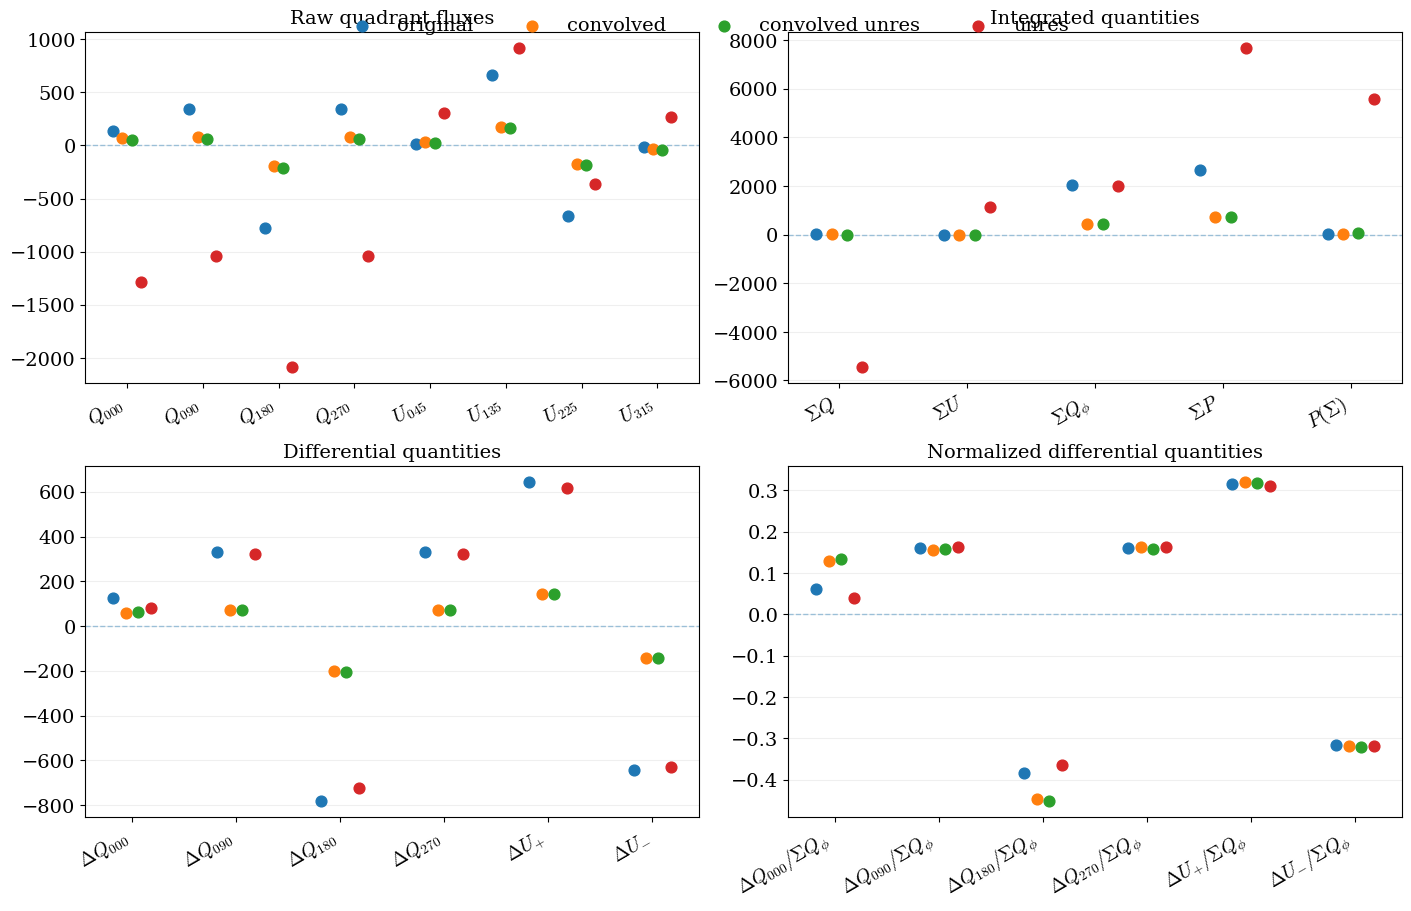

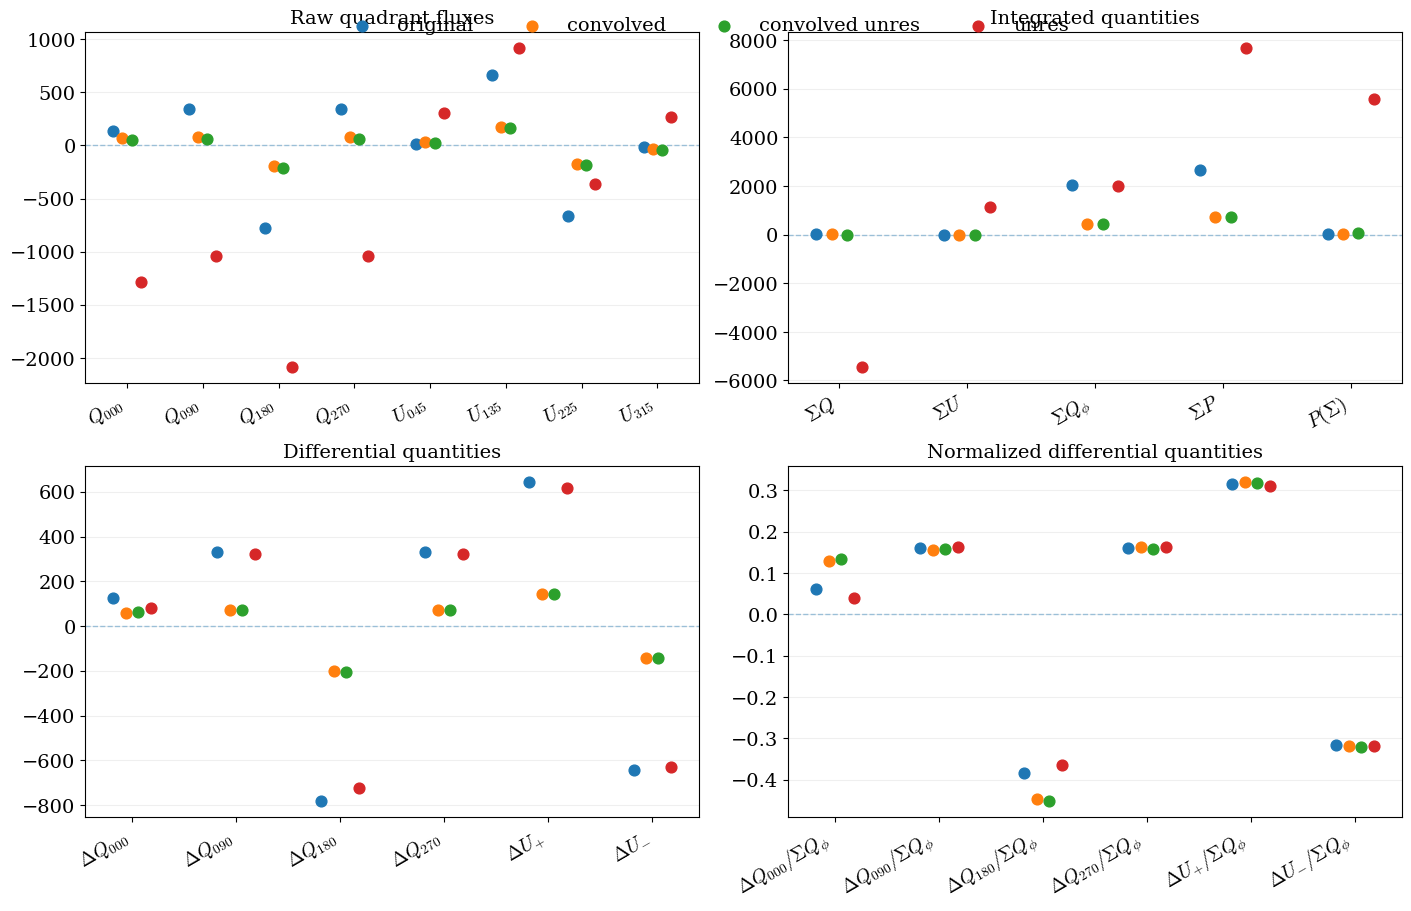

In [23]:
fig,axes=plot_quadrant_comparison([result_orig, result_conv, result_conv_unres, result_unres],
    labels=['original', 'convolved', 'convolved unres', 'unres'],
    figsize=(14, 9),
    marker_size=60)

fig



In [24]:
import SMAC3 as smac3py

work_root = "/fred/oz061/kandrych/smac/testing_poalimerty_jpnb/"

max_fidelity = smac3py.map_budget_to_fidelity(16.1)
data_arg = smac3py.load_data('demo_ozstar', str(work_root),max_fidelity["products"])

pdi_data_v = data_arg[5] #each disc with data not deconvolved q_phi, u_phi, pi, and psf

pdi_data_i = data_arg[6] 

pdi_data_h = data_arg[7]

Polarimetric data loaded
data loaded


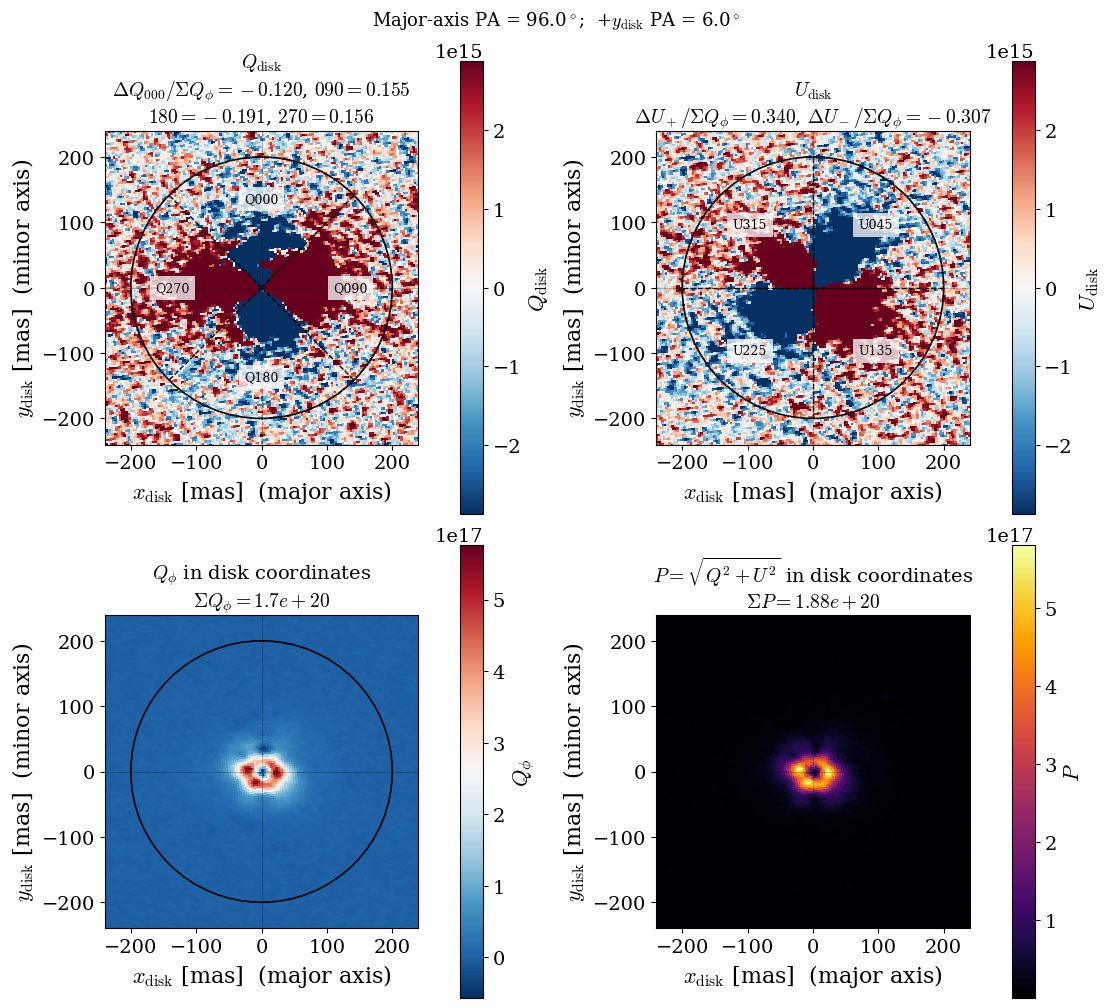

In [28]:

disk_pa_deg=96
r_out_quadrants=200
workdir=work_root
quadrant_results_data_h = differential_quadrants(pdi_data_i['pol_images']['Q']*10**(-order), pdi_data_i['pol_images']['U']*10**(-order), pixel_scale_mas=results_i['mcfost_convolved']['pixel_scale_mas'], disk_pa_deg=disk_pa_deg, r_in_mas=0, r_out_mas=r_out_quadrants, flip_disk_y=False, plot=True, save=str(workdir)+'quadrants_h_data.png', roi_mas=None)


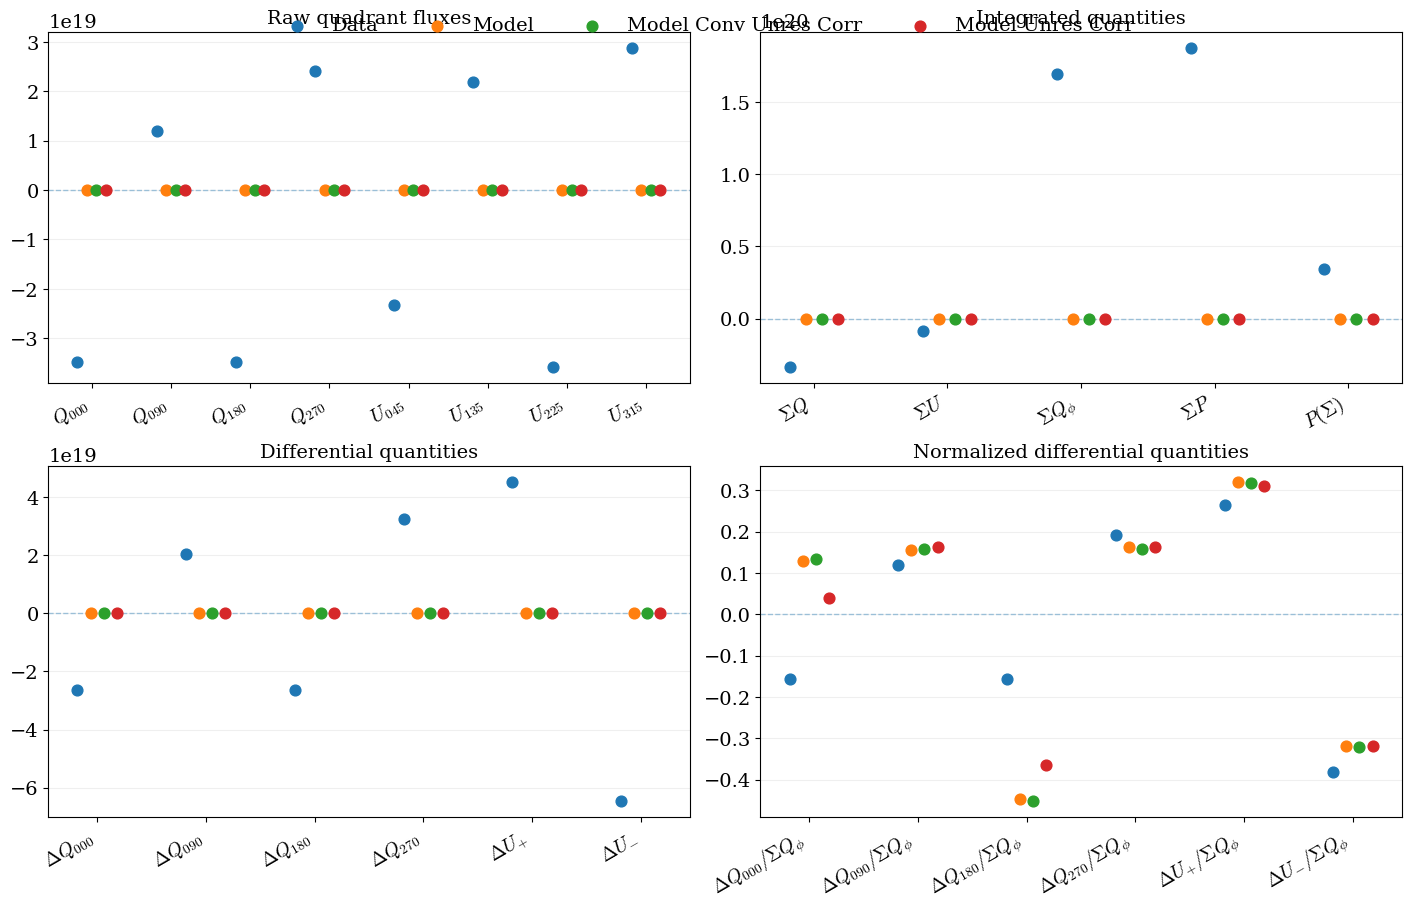

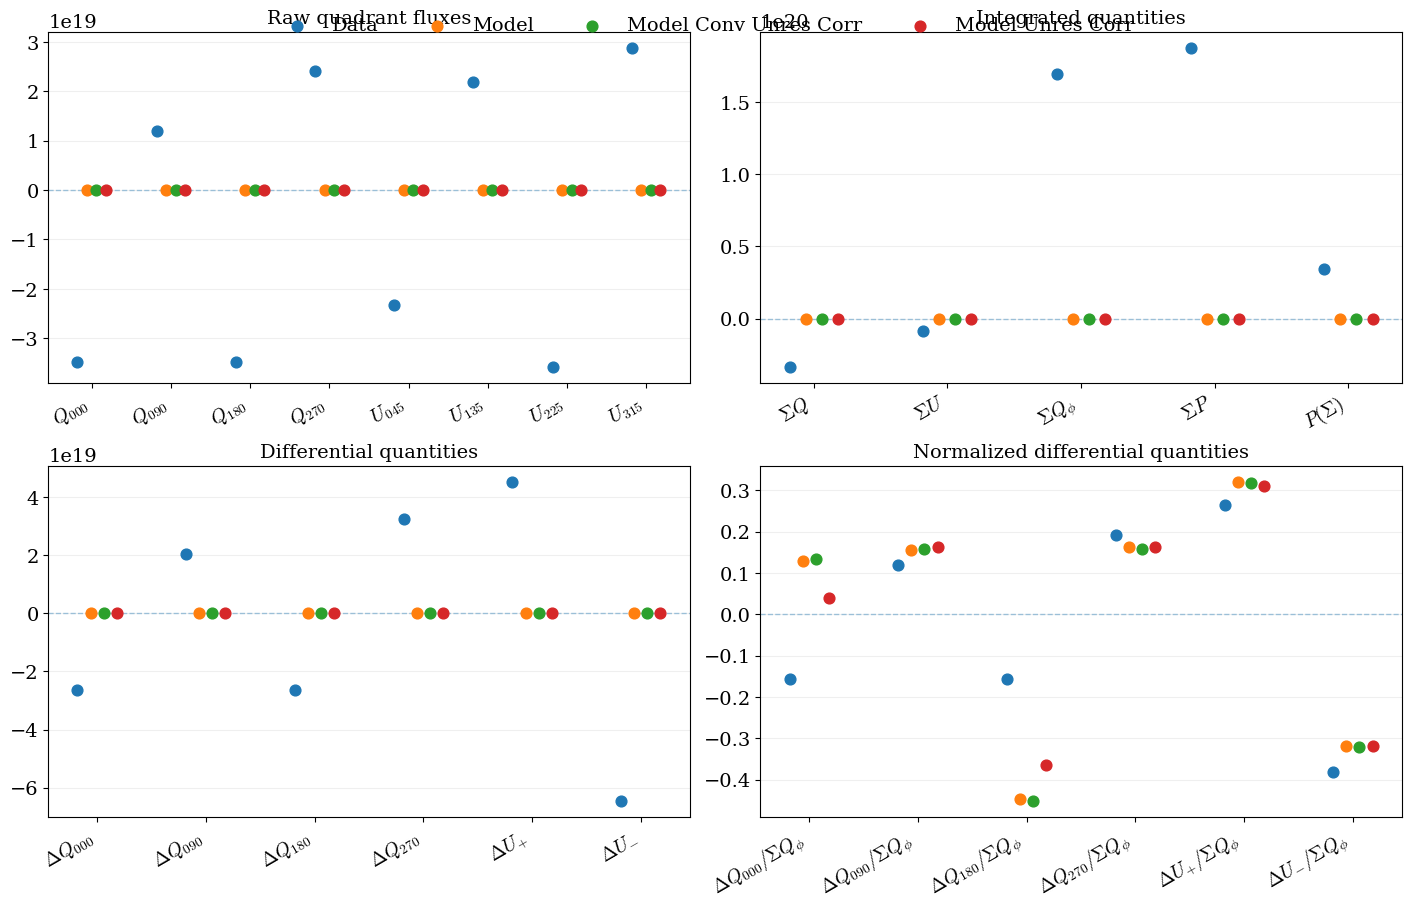

In [17]:
fig,axes=obp.plot_quadrant_comparison([quadrant_results_data_h, result_conv, result_conv_unres, result_unres], ['Data', 'Model', 'Model Conv Unres Corr', 'Model Unres Corr'], save=str(workdir)+'quadrants_h_comparison.png')
fig

In [39]:
## Just for data slide

def differential_quadrants_data_slides(
    Q,
    U,
    pixel_scale_mas,
    disk_pa_deg,
    r_in_mas,
    r_out_mas,
    *,
    flip_disk_y=False,
    plot=False,
    save=None,
    title=None,
    roi_mas=None,
):
    """
    Calculate Schmid differential quadrant parameters.

    Coordinate convention
    ---------------------
    Input images:
        +X_sky = East
        +Y_sky = North

    disk_pa_deg:
        Position angle of the DISK MAJOR AXIS,
        measured North -> East.

    Schmid disk coordinates:
        +x_disk = along disk major axis
        +y_disk = along disk minor axis

        phi_disk = atan2(x_disk, y_disk)

        so:
            phi =   0 deg : +y_disk
            phi =  90 deg : +x_disk
            phi = 180 deg : -y_disk
            phi = 270 deg : -x_disk

    flip_disk_y:
        If False, +y_disk is chosen 90 deg counter-clockwise
        from +x_disk in the PA convention.
        Set True if the opposite minor-axis direction should
        correspond to +y_disk (e.g. to make +y the disk backside).

    Notes
    -----
    - No scipy image rotation/interpolation is performed.
    - Q/U are rotated analytically into the disk Stokes basis.
    - Quadrants are defined in disk coordinates.
    - Q_phi and P are recomputed in the disk frame as a consistency check.
    - P = sqrt(Q^2 + U^2) is invariant under coordinate rotation.

    Returns
    -------
    dict
        Raw quadrant sums, differential quadrant values,
        normalized differential values, and coordinate/validation
        quantities useful for diagnostics.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle

    # =========================================================
    # 0. Basic checks
    # =========================================================

    Q = np.asarray(Q, dtype=float)
    U = np.asarray(U, dtype=float)

    if Q.shape != U.shape:
        raise ValueError(
            f"Q and U must have the same shape: "
            f"Q={Q.shape}, U={U.shape}"
        )

    if r_out_mas <= r_in_mas:
        raise ValueError("r_out_mas must be larger than r_in_mas.")

    # =========================================================
    # 1. Sky coordinates
    # =========================================================

    ny, nx = Q.shape

    yc = (ny - 1) / 2.0
    xc = (nx - 1) / 2.0

    yy, xx = np.indices(Q.shape)

    # Astronomical sky convention:
    # +X = East
    # +Y = North
    X = (xx - xc) * pixel_scale_mas
    Y = -(yy - yc) * pixel_scale_mas

    R = np.sqrt(X**2 + Y**2)

    # PA measured from North toward East
    phi_sky = np.arctan2(X, Y)

    # =========================================================
    # 2. Define Schmid disk coordinate system
    # =========================================================

    # Input PA is MAJOR-axis PA.
    pa_major = np.deg2rad(disk_pa_deg)

    # In Schmid coordinates:
    #
    #   +x_disk = major axis
    #   +y_disk = minor axis
    #
    # Since phi = atan2(x,y), +x occurs 90 deg from +y.
    #
    # Therefore:
    # PA(+y_disk) = PA(+x_disk) - 90 deg

    w = pa_major - np.pi / 2.0

    if flip_disk_y:
        # Reverse both disk axes.
        #
        # Note: this does NOT change the Q/U Stokes basis because
        # Stokes Q,U are invariant under a 180-deg axis reversal,
        # but it DOES swap the physical quadrant labels.
        w += np.pi

    # =========================================================
    # 3. Spatial coordinates in disk frame
    # =========================================================

    # This is a passive coordinate transformation.
    #
    # A point exactly along +y_disk should give:
    # Xd = 0, Yd > 0

    Xd = X * np.cos(w) - Y * np.sin(w)
    Yd = X * np.sin(w) + Y * np.cos(w)

    # Schmid azimuth:
    # phi = atan2(x_disk, y_disk)
    phi = np.arctan2(Xd, Yd)
    phi_mod = phi % (2.0 * np.pi)

    # Useful consistency check:
    phi_from_sky = np.angle(
        np.exp(1j * (phi_sky - w))
    )

    # =========================================================
    # 4. Rotate Stokes Q/U basis into disk coordinates
    # =========================================================

    cos2w = np.cos(2.0 * w)
    sin2w = np.sin(2.0 * w)

    Qd = Q * cos2w + U * sin2w
    Ud = U * cos2w - Q * sin2w

    # =========================================================
    # 5. Q_phi, U_phi and P in disk coordinates
    # =========================================================

    # Schmid & Ma equations:
    #
    # Q_phi = -Q cos(2phi) - U sin(2phi)
    # U_phi = +Q sin(2phi) - U cos(2phi)

    Qphi_disk = (
        -Qd * np.cos(2.0 * phi)
        -Ud * np.sin(2.0 * phi)
    )

    Uphi_disk = (
        +Qd * np.sin(2.0 * phi)
        -Ud * np.cos(2.0 * phi)
    )

    # Polarized flux P.
    # This is invariant under the Q/U reference-frame rotation.
    P_disk = np.sqrt(Qd**2 + Ud**2)

    # Calculate using your existing routine as a cross-check
    Qphi_sky, Uphi_sky, P_sky, _ = obp.compute_qphi_uphi_pi(Q, U)

    finite = (
        np.isfinite(Qphi_disk)
        & np.isfinite(Qphi_sky)
    )

    if np.any(finite):
        max_qphi_difference = np.nanmax(
            np.abs(Qphi_disk[finite] - Qphi_sky[finite])
        )
    else:
        max_qphi_difference = np.nan

    finite_p = (
        np.isfinite(P_disk)
        & np.isfinite(P_sky)
    )

    if np.any(finite_p):
        max_p_difference = np.nanmax(
            np.abs(P_disk[finite_p] - P_sky[finite_p])
        )
    else:
        max_p_difference = np.nan

    # =========================================================
    # 6. Integration aperture
    # =========================================================

    aperture = (
        (R >= r_in_mas)
        & (R <= r_out_mas)
        & np.isfinite(Qd)
        & np.isfinite(Ud)
    )

    # =========================================================
    # 7. Non-overlapping quadrant masks
    # =========================================================

    def angular_difference(phi_array, center_deg):
        """
        Wrapped angular difference in [-pi, pi).
        """
        center = np.deg2rad(center_deg)

        return np.angle(
            np.exp(1j * (phi_array - center))
        )

    def wedge(center_deg):
        """
        90-degree wedge centred on center_deg.

        The lower boundary is included and the upper boundary
        excluded so neighbouring wedges cannot double-count pixels.
        """
        dphi = angular_difference(phi, center_deg)

        return (
            aperture
            & (dphi >= -np.pi / 4.0)
            & (dphi <  np.pi / 4.0)
        )

    # =========================================================
    # 8. Q quadrants
    # =========================================================

    Q000 = np.nansum(Qd[wedge(0)])
    Q090 = np.nansum(Qd[wedge(90)])
    Q180 = np.nansum(Qd[wedge(180)])
    Q270 = np.nansum(Qd[wedge(270)])

    # =========================================================
    # 9. U quadrants
    # =========================================================

    U045 = np.nansum(Ud[wedge(45)])
    U135 = np.nansum(Ud[wedge(135)])
    U225 = np.nansum(Ud[wedge(225)])
    U315 = np.nansum(Ud[wedge(315)])

    # =========================================================
    # 10. Integrated quantities
    # =========================================================

    # Better than summing the four quadrant values because this
    # guarantees every aperture pixel is counted exactly once.
    SigmaQ = np.nansum(Qd[aperture])
    SigmaU = np.nansum(Ud[aperture])

    # Use Qphi calculated self-consistently in disk coordinates.
    SigmaQphi = np.nansum(Qphi_disk[aperture])

    # Pixel-wise integrated polarized flux:
    #
    # SigmaP = sum sqrt(Q^2 + U^2)
    #
    # Note: this is NOT the same as aperture polarization:
    # P(Sigma) = sqrt[(SigmaQ)^2 + (SigmaU)^2]
    SigmaP = np.nansum(P_disk[aperture])

    P_aperture = np.sqrt(SigmaQ**2 + SigmaU**2)

    # =========================================================
    # 11. Differential quadrant parameters
    # =========================================================

    dQ000 = Q000 - SigmaQ / 4.0
    dQ090 = Q090 - SigmaQ / 4.0
    dQ180 = Q180 - SigmaQ / 4.0
    dQ270 = Q270 - SigmaQ / 4.0

    dUplus = U135 - U045
    dUminus = U225 - U315

    # Relative quantities only meaningful if SigmaQphi != 0.
    valid = (
        np.isfinite(SigmaQphi)
        and not np.isclose(
            SigmaQphi,
            0.0,
            atol=1e-12,
            rtol=0.0
        )
    )

    if valid:

        dQ000_norm = dQ000 / SigmaQphi
        dQ090_norm = dQ090 / SigmaQphi
        dQ180_norm = dQ180 / SigmaQphi
        dQ270_norm = dQ270 / SigmaQphi

        dUplus_norm = dUplus / SigmaQphi
        dUminus_norm = dUminus / SigmaQphi

    else:

        print(
            f"Warning: SigmaQphi ~ 0 in annulus "
            f"{r_in_mas}..{r_out_mas} mas. "
            "Normalized quadrant quantities set to NaN."
        )

        dQ000_norm = np.nan
        dQ090_norm = np.nan
        dQ180_norm = np.nan
        dQ270_norm = np.nan

        dUplus_norm = np.nan
        dUminus_norm = np.nan

    # =========================================================
    # 12. Results
    # =========================================================

    result = {

        # Raw Q quadrants
        "Q000": Q000,
        "Q090": Q090,
        "Q180": Q180,
        "Q270": Q270,

        # Raw U quadrants
        "U045": U045,
        "U135": U135,
        "U225": U225,
        "U315": U315,

        # Integrated quantities
        "SigmaQ": SigmaQ,
        "SigmaU": SigmaU,
        "SigmaQphi": SigmaQphi,
        "SigmaP": SigmaP,
        "P_aperture": P_aperture,

        # Raw differential quantities
        "dQ000": dQ000,
        "dQ090": dQ090,
        "dQ180": dQ180,
        "dQ270": dQ270,

        "dUplus": dUplus,
        "dUminus": dUminus,

        # Normalized differential quantities
        "dQ000_norm": dQ000_norm,
        "dQ090_norm": dQ090_norm,
        "dQ180_norm": dQ180_norm,
        "dQ270_norm": dQ270_norm,

        "dUplus_norm": dUplus_norm,
        "dUminus_norm": dUminus_norm,

        "valid": valid,

        # Geometry
        "disk_pa_major_deg": disk_pa_deg,
        "disk_y_pa_deg": np.rad2deg(w) % 360.0,
        "flip_disk_y": flip_disk_y,

        # Useful maps
        "Q_disk": Qd,
        "U_disk": Ud,
        "Qphi_disk": Qphi_disk,
        "Uphi_disk": Uphi_disk,
        "P_disk": P_disk,

        "X_disk": Xd,
        "Y_disk": Yd,
        "R": R,
        "phi_disk": phi_mod,
        "aperture": aperture,

        # Coordinate / convention diagnostics
        "max_Qphi_coordinate_difference": max_qphi_difference,
        "max_P_coordinate_difference": max_p_difference,
    }

    # =========================================================
    # 13. Diagnostic plots
    # =========================================================

    if plot:

        if roi_mas is None:
            roi_mas = 1.2 * r_out_mas

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(11, 10),
            constrained_layout=True
        )

        axQ = axes[0, 0]
        axU = axes[0, 1]
        axQphi = axes[1, 0]
        axP = axes[1, 1]

        # -----------------------------------------------------
        # Plot helpers
        # -----------------------------------------------------

        def draw_radial_line(
            ax,
            angle_deg,
            radius,
            **kwargs
        ):
            """
            Disk angle measured from +y toward +x.
            """
            a = np.deg2rad(angle_deg)

            x_end = radius * np.sin(a)
            y_end = radius * np.cos(a)

            ax.plot(
                [0, x_end],
                [0, y_end],
                **kwargs
            )

        def annotate_quadrant(
            ax,
            angle_deg,
            radius,
            text
        ):
            a = np.deg2rad(angle_deg)

            x_text = radius * np.sin(a)
            y_text = radius * np.cos(a)

            ax.text(
                x_text,
                y_text,
                text,
                ha="center",
                va="center",
                fontsize=9,
                bbox=dict(
                    facecolor="white",
                    alpha=0.75,
                    edgecolor="none"
                )
            )

        def add_aperture(ax):
            ax.add_patch(
                Circle(
                    (0, 0),
                    r_in_mas,
                    fill=False,
                    ls=":",
                    lw=1.2,
                    color="k"
                )
            )

            ax.add_patch(
                Circle(
                    (0, 0),
                    r_out_mas,
                    fill=False,
                    ls="-",
                    lw=1.2,
                    color="k"
                )
            )

        def format_disk_axes(ax):
            ax.axhline(
                0,
                lw=0.5,
                alpha=0.35,
                color="k"
            )

            ax.axvline(
                0,
                lw=0.5,
                alpha=0.35,
                color="k"
            )

            ax.set_xlim(-roi_mas, roi_mas)
            ax.set_ylim(-roi_mas, roi_mas)

            ax.set_aspect("equal")

            ax.set_xlabel(
                r"$x_{\rm disk}$ [mas]  (major axis)"
            )

            ax.set_ylabel(
                r"$y_{\rm disk}$ [mas]  (minor axis)"
            )

        # -----------------------------------------------------
        # Common Q/U scale
        # -----------------------------------------------------

        qu_values = np.concatenate([
            np.abs(Qd[np.isfinite(Qd)]),
            np.abs(Ud[np.isfinite(Ud)])
        ])

        vmax_qu = np.nanpercentile(
            qu_values,
            99
        )

        if (
            not np.isfinite(vmax_qu)
            or vmax_qu == 0
        ):
            vmax_qu = 1.0

        # =====================================================
        # Q_disk
        # =====================================================

        imQ = axQ.pcolormesh(
            Xd,
            Yd,
            Qd,
            shading="auto",
            cmap="RdBu_r",
        )

        # Q centres:
        # 0, 90, 180, 270
        #
        # boundaries:
        # 45, 135, 225, 315
        for angle in [45, 135, 225, 315]:
            draw_radial_line(
                axQ,
                angle,
                r_out_mas,
                color="k",
                lw=1,
                ls="--"
            )

        add_aperture(axQ)

        r_label = (
            r_in_mas
            + 0.68 * (r_out_mas - r_in_mas)
        )

        annotate_quadrant(
            axQ, 0, r_label, "Q000"
        )
        annotate_quadrant(
            axQ, 90, r_label, "Q090"
        )
        annotate_quadrant(
            axQ, 180, r_label, "Q180"
        )
        annotate_quadrant(
            axQ, 270, r_label, "Q270"
        )

        if valid:
            axQ.set_title(
                r"$Q_{\rm disk}$"
                
            )
        else:
            axQ.set_title(
                r"$Q_{\rm disk}$"
                
            )

        format_disk_axes(axQ)

       
        # =====================================================
        # U_disk
        # =====================================================

        imU = axU.pcolormesh(
            Xd,
            Yd,
            Ud,
            shading="auto",
            cmap="RdBu_r"
        )

        # U centres:
        # 45,135,225,315
        #
        # boundaries:
        # 0,90,180,270
        for angle in [0, 90, 180, 270]:
            draw_radial_line(
                axU,
                angle,
                r_out_mas,
                color="k",
                lw=1,
                ls="--"
            )

        add_aperture(axU)

        annotate_quadrant(
            axU, 45, r_label, "U045"
        )
        annotate_quadrant(
            axU, 135, r_label, "U135"
        )
        annotate_quadrant(
            axU, 225, r_label, "U225"
        )
        annotate_quadrant(
            axU, 315, r_label, "U315"
        )

        
        axU.set_title(
            r"$U_{\rm disk}$"
        )

        format_disk_axes(axU)

       

        # =====================================================
        # Q_phi
        # =====================================================

        imQphi = axQphi.pcolormesh(
            Xd,
            Yd,
            Qphi_disk,
            shading="auto",
            cmap="inferno"
        )

        format_disk_axes(axQphi)

        axQphi.set_title(
            r"$Q_\phi$ in disk coordinates"
            
        )

        

        # =====================================================
        # Polarized flux P
        # =====================================================

        p_values = P_disk[np.isfinite(P_disk)]

        vmax_p = np.nanpercentile(
            p_values,
            100
        )

        if (
            not np.isfinite(vmax_p)
            or vmax_p == 0
        ):
            vmax_p = 1.0

        imP = axP.pcolormesh(
            Xd,
            Yd,
            P_disk,
            shading="auto",
            cmap="inferno"
        )

        add_aperture(axP)
        format_disk_axes(axP)

        axP.set_title(
            r"$P=\sqrt{Q^2+U^2}$ in disk coordinates"
            "\n"
            rf"$\Sigma P={SigmaP:.3g}$"
        )


        # =====================================================
        # Overall title
        # =====================================================

        base_title = (
            rf"Major-axis PA = {disk_pa_deg:.1f}$^\circ$"
            rf";  +$y_{{\rm disk}}$ PA = "
            rf"{np.rad2deg(w) % 360:.1f}$^\circ$"
        )

        if title is not None:
            fig.suptitle(
                title + "\n" + base_title,
                fontsize=13
            )
        else:
            fig.suptitle(
                base_title,
                fontsize=13
            )

        if save is not None:
            fig.savefig(
                save,
                dpi=200,
                bbox_inches="tight"
            )

        plt.show()

    return result

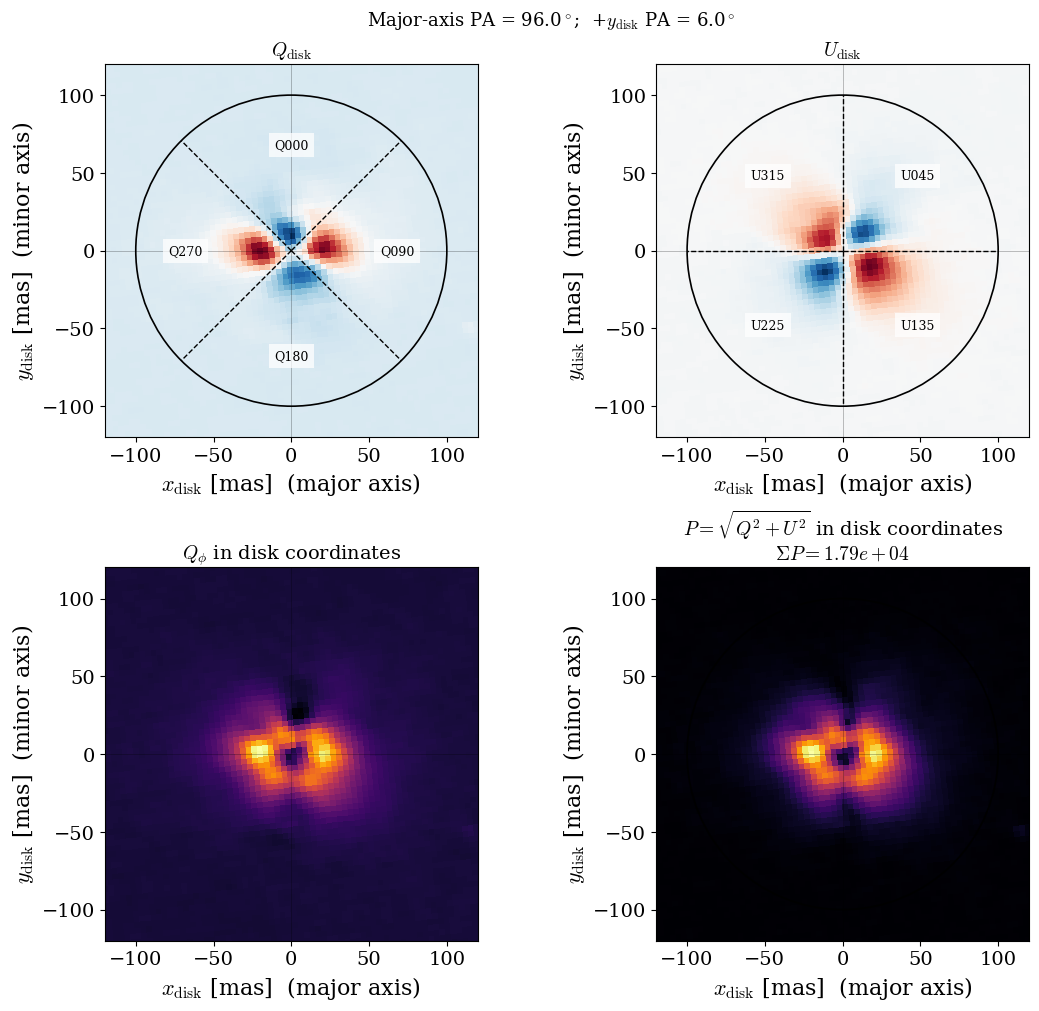

In [43]:

disk_pa_deg=96
r_out_quadrants=100
workdir=work_root
quadrant_results_data_h = differential_quadrants_data_slides(pdi_data_v['pol_images']['Q'], pdi_data_v['pol_images']['U'], pixel_scale_mas=results_i['mcfost_convolved']['pixel_scale_mas'], disk_pa_deg=disk_pa_deg, r_in_mas=0, r_out_mas=r_out_quadrants, flip_disk_y=False, plot=True, save=str(workdir)+'quadrants_h_data.png', roi_mas=None)
